In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import utils as util
from astropy.cosmology import Planck15
from astropy import units as u

In [2]:
import scienceplots
plt.style.use(['science'])
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [3]:
import arepo_package as arepo

In [4]:
#loading TNG-50 first

pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[0,0,10,1])
    brahma_control = control.control_sample_brahma(brahma_pop_Nstar10)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=10)
    


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.3,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


processing each merger redshifts for controls:   0%|          | 0/83 [00:00<?, ?it/s]

processing each merger redshifts for controls: 100%|██████████| 83/83 [00:01<00:00, 42.11it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:381: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 14
SM5_TNG


processing each merger redshifts for controls: 100%|██████████| 16/16 [00:00<00:00, 26.20it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:609: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


...

Number of cases where a close enough match is not found within the acceptable tolerance: 328
number of processable mergers with valid controls:
795
[55, 67, 91, 100, 105, 149, 120, 69, 21, 14]
SM5_LW10_LOWSPIN_TNG


processing each merger redshifts for controls: 100%|██████████| 17/17 [00:00<00:00, 45.25it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 80
number of processable mergers with valid controls:
405
[28, 22, 29, 41, 44, 91, 59, 35, 26, 19, 11]
SM5_LW10_LOWSPIN_RICH_TNG


processing each merger redshifts for controls: 100%|██████████| 18/18 [00:00<00:00, 113.35it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 49
number of processable mergers with valid controls:
127
[12, 24, 14, 25, 12, 17, 11, 10]
[55, 57, 54, 63, 65, 57, 70, 50]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 3.8]
Brahma common zbins: [0.  0.4 1.  1.6 2.2 3.1 4.1 5.1 8.1]


In [5]:
brahma_sim_zbins

{'SM5_TNG': array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 2.1, 3.1, 4.1, 5.1, 6.1]),
 'SM5_LW10_TNG': array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 2.1, 3.1, 4.1, 5.1, 6.1]),
 'SM5_DFD_3_TNG': array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 2.1, 3.1, 4.1, 5.1, 6.1]),
 'SM5_LW10_DFD_3_TNG': array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 2.1, 3.1, 4.1, 5.1, 6.1]),
 'SM5_LW10_LOWSPIN_TNG': array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 2.1, 3.1, 4.1, 5.1, 6.1, 9.1]),
 'SM5_LW10_LOWSPIN_RICH_TNG': array([0. , 0.4, 1. , 1.6, 2.2, 3.1, 4.1, 5.1, 8.1])}

In [6]:
snap,red = arepo.get_snapshot_redshift_correspondence(simPath)

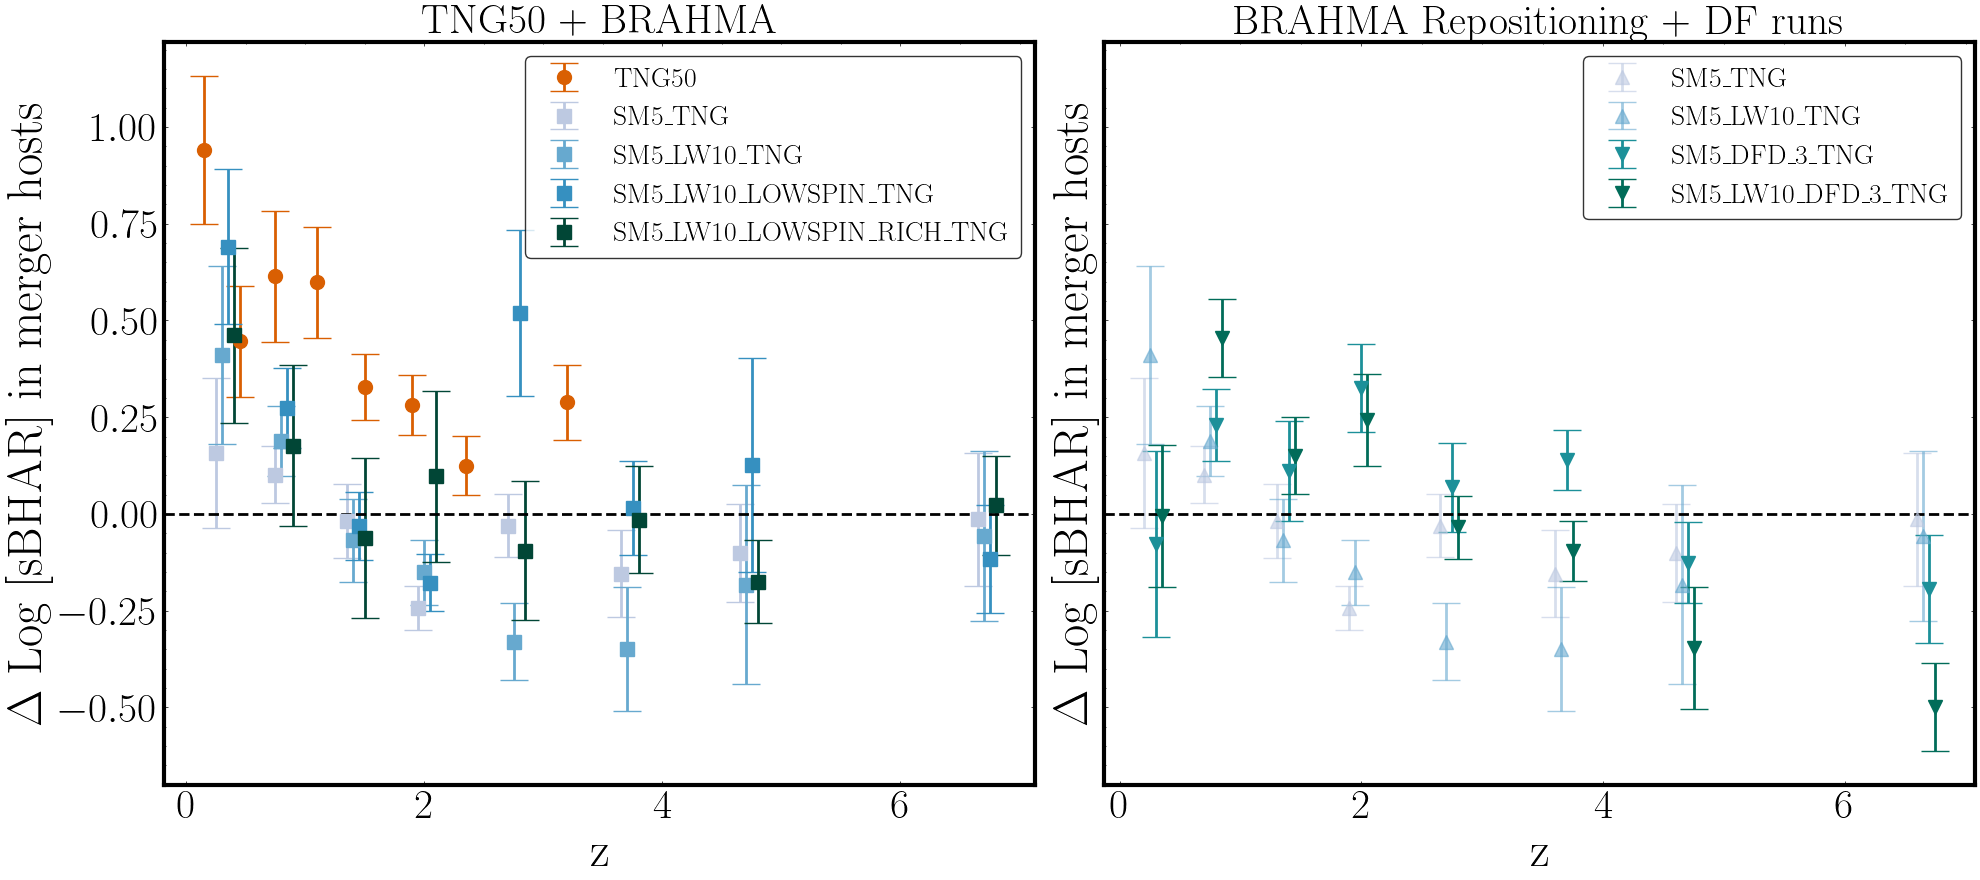

In [7]:
# sSFR Enhancement plots: TNG50 + BRAHMA (left) vs Repositioning + DFD (right)

# Define simulation groups
tng_sims = ['TNG50']
brahma_non_dfd = ['SM5_TNG', 'SM5_LW10_TNG', 'SM5_LW10_LOWSPIN_TNG', 'SM5_LW10_LOWSPIN_RICH_TNG']
brahma_dfd = ['SM5_DFD_3_TNG', 'SM5_LW10_DFD_3_TNG']

# Set up plot style
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=20,bold=True)

# Create figure with 1x2 subplots
fig, ax = plt.subplots(1, 2, figsize=(20,9),sharey=True)

# Left subplot: TNG50 + all BRAHMA non-DFD sims
z_offset_left = 0.05
i = 0
# Plot TNG50
avg_sBHAR, std_sBHAR = util.merger_enhancement_calc(sim_objs['TNG50'], 'sBHAR', sim_zbins_list['TNG50'], log=True)
z_mid = sim_zbins_list['TNG50'][:-1] + np.diff(sim_zbins_list['TNG50']) / 2
ax[0].errorbar(z_mid, avg_sBHAR, yerr=std_sBHAR, fmt='o', capsize=10, markersize=10, 
               label='TNG50', color=sim_colors['TNG50'], alpha=1, linewidth=2)

# Plot BRAHMA non-DFD sims
for j, sim in enumerate(brahma_non_dfd):
    avg_sBHAR, std_sBHAR = util.merger_enhancement_calc(sim_objs[sim], 'sBHAR', sim_zbins_list[sim], log=True)
    z_mid = sim_zbins_list[sim][:-1] + np.diff(sim_zbins_list[sim]) / 2
    ax[0].errorbar(z_mid + z_offset_left * (j + 1), avg_sBHAR, yerr=std_sBHAR, fmt='s', capsize=10, 
                   markersize=10, label=sim, color=sim_colors[sim], alpha=1, linewidth=2)

ax[0].axhline(0, ls='--', color='black', linewidth=2)
ax[0].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[0].set_xlabel('z')
ax[0].set_title('TNG50 + BRAHMA')
ax[0].legend(frameon=True, edgecolor='black')
#ax[0].grid(True, alpha=0.3)

# Right subplot: Non-DFD BRAHMA vs DFD BRAHMA
z_offset_right = 0.05
# Plot non-DFD sims
brahma_non_dfd = ['SM5_TNG', 'SM5_LW10_TNG']
for j, sim in enumerate(brahma_non_dfd):
    avg_sBHAR, std_sBHAR = util.merger_enhancement_calc(sim_objs[sim], 'sBHAR', sim_zbins_list[sim], log=True)
    z_mid = sim_zbins_list[sim][:-1] + np.diff(sim_zbins_list[sim]) / 2
    ax[1].errorbar(z_mid + z_offset_right * j, avg_sBHAR, yerr=std_sBHAR, fmt='^', capsize=10, 
                   markersize=10, label=sim , color=sim_colors[sim], alpha=0.6, linewidth=2)

# Plot DFD sims
for j, sim in enumerate(brahma_dfd):
    avg_sBHAR, std_sBHAR = util.merger_enhancement_calc(sim_objs[sim], 'sBHAR', sim_zbins_list[sim], log=True)
    z_mid = sim_zbins_list[sim][:-1] + np.diff(sim_zbins_list[sim]) / 2
    ax[1].errorbar(z_mid + z_offset_right * (j + len(brahma_non_dfd)), avg_sBHAR, yerr=std_sBHAR, fmt='v', 
                   capsize=10, markersize=10, label=sim, color=sim_colors[sim], alpha=1, linewidth=2)

ax[1].axhline(0, ls='--', color='black', linewidth=2)
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlabel('z')
ax[1].set_title('BRAHMA Repositioning + DF runs ')
ax[1].legend(frameon=True, edgecolor='black')
#ax[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("../../figures/sBHAR_enhancement_TNG_and_BRAHMA.pdf")

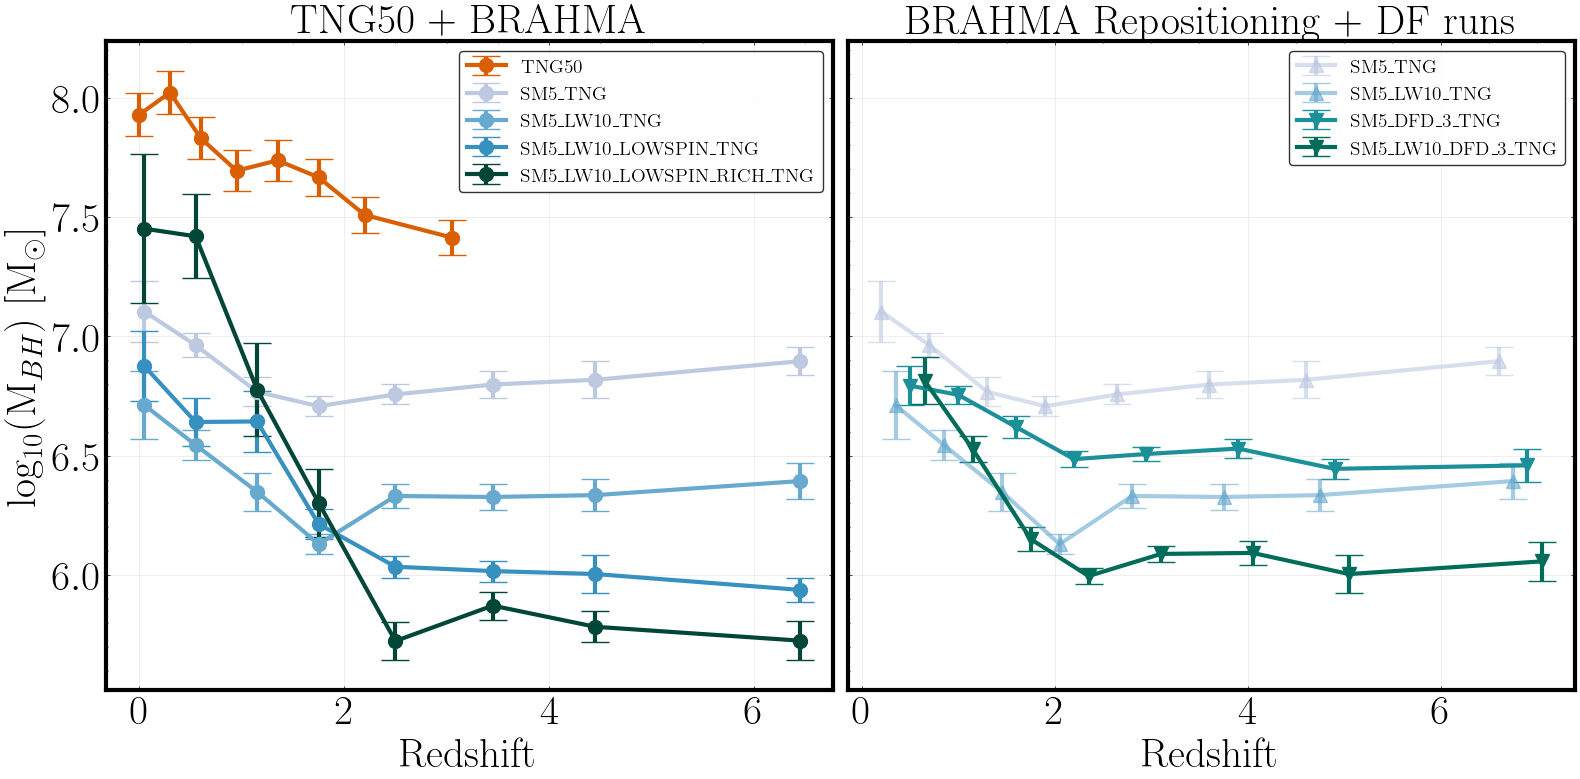


Black Hole Mass Summary (Merging Population):
Simulation                     Mean log10(Mbh)      Std Dev             
--------------------------------------------------------------------------------
SM5_TNG                        6.852                0.122               
SM5_LW10_TNG                   6.390                0.161               
SM5_DFD_3_TNG                  6.575                0.126               
SM5_LW10_DFD_3_TNG             6.216                0.276               
SM5_LW10_LOWSPIN_TNG           6.296                0.343               
SM5_LW10_LOWSPIN_RICH_TNG      6.382                0.695               
TNG50                          7.725                0.190               


In [8]:
# Calculate black hole mass at redshift bins
sim_logMbh = {}
for sim in sim_names:
    Mbh_merging = sim_objs[sim].MBH_merging_pop
    z_bins = sim_zbins_list[sim]
    Mbh_avg = []
    Mbh_error = []
    for i in range(len(z_bins)-1):
        z_low = z_bins[i]
        z_high = z_bins[i+1]
        z_mask = (sim_objs[sim].z_merging_pop >= z_low) & (sim_objs[sim].z_merging_pop < z_high)
        Mbh_in_bin = np.log10(Mbh_merging[z_mask])
        Mbh_avg.append(np.mean(Mbh_in_bin))
        Mbh_error.append(stats.sem(Mbh_in_bin))
    Mbh_avg = np.array(Mbh_avg)
    Mbh_error = np.array(Mbh_error)
    sim_logMbh[sim]={
        'mean': Mbh_avg,
        'sem': Mbh_error  
    }

# Plot black hole mass evolution across redshift
hostplot.set_plot_style(spinewidth=3, linewidth=3, titlesize=30, labelsize=35, xlabelsize=30, ylabelsize=30, legendsize=18, bold=True)

# Separate simulations into groups
tng_sims_mbh = [sim for sim in sim_names if 'TNG50' in sim or sim == 'TNG50']
brahma_non_dfd_mbh = [sim for sim in sim_names if 'DFD' not in sim and 'TNG50' not in sim]
brahma_dfd_mbh = [sim for sim in sim_names if 'DFD' in sim]

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(16, 8))

# Plot left panel: TNG50 + BRAHMA non-DFD
z_offset_left = -0.15
for j, sim in enumerate(tng_sims_mbh):
    z_bins = sim_zbins_list[sim]
    z_plot = (z_bins[:-1] + z_bins[1:]) / 2 + z_offset_left
    ax1.errorbar(z_plot, sim_logMbh[sim]['mean'], yerr=sim_logMbh[sim]['sem'], 
                 marker='o', markersize=10, capsize=10, linewidth=3, 
                 label=sim, color=sim_colors[sim], alpha=1)

for j, sim in enumerate(brahma_non_dfd_mbh):
    z_bins = sim_zbins_list[sim]
    z_plot = (z_bins[:-1] + z_bins[1:]) / 2 + z_offset_left
    ax1.errorbar(z_plot, sim_logMbh[sim]['mean'], yerr=sim_logMbh[sim]['sem'], 
                 marker='o', markersize=10, capsize=10, linewidth=3, 
                 label=sim, color=sim_colors[sim], alpha=1)

ax1.set_xlabel('Redshift', fontsize=30)
ax1.set_ylabel('log$_{10}$(M$_{BH}$) [M$_\\odot$]', fontsize=30)
ax1.set_title('TNG50 + BRAHMA', fontsize=30, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(frameon=True, edgecolor='black', fontsize=14, loc='best')

# Plot right panel: BRAHMA DFD simulations with non-DFD comparison
z_offset_right = 0.15
# Plot non-DFD sims first
non_dfd_to_compare = ['SM5_TNG', 'SM5_LW10_TNG']
for j, sim in enumerate(non_dfd_to_compare):
    z_bins = sim_zbins_list[sim]
    z_plot = (z_bins[:-1] + z_bins[1:]) / 2 + z_offset_right * j
    ax2.errorbar(z_plot, sim_logMbh[sim]['mean'], yerr=sim_logMbh[sim]['sem'], 
                 marker='^', markersize=10, capsize=10, linewidth=3, 
                 label=sim, color=sim_colors[sim], alpha=0.6)

# Plot DFD sims
for j, sim in enumerate(brahma_dfd_mbh):
    z_bins = sim_zbins_list[sim]
    z_plot = (z_bins[:-1] + z_bins[1:]) / 2 + z_offset_right * (j + len(non_dfd_to_compare))
    ax2.errorbar(z_plot, sim_logMbh[sim]['mean'], yerr=sim_logMbh[sim]['sem'], 
                 marker='v', markersize=10, capsize=10, linewidth=3, 
                 label=sim, color=sim_colors[sim], alpha=1)

ax2.set_xlabel('Redshift', fontsize=30)
ax2.set_title('BRAHMA Repositioning + DF runs', fontsize=30, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=True, edgecolor='black', fontsize=14, loc='best')

fig.tight_layout()
plt.show()

# Print summary
print("\nBlack Hole Mass Summary (Merging Population):")
print("=" * 80)
print(f"{'Simulation':<30} {'Mean log10(Mbh)':<20} {'Std Dev':<20}")
print("-" * 80)
for sim in sim_names:
    mean_mbh = np.mean(sim_logMbh[sim]['mean'])
    std_mbh = np.std(sim_logMbh[sim]['mean'])
    print(f"{sim:<30} {mean_mbh:<20.3f} {std_mbh:<20.3f}")


#### Summary statistics of sBHAR in mergers vs controls across simulations

In [9]:
summary_enhancement ={}

for sim in sim_names:
    sim_obj = sim_objs[sim]
    sBHAR_merging = sim_obj.sBHAR_merging_pop
    sBHAR_control = sim_obj.sBHAR_control_pop

    # Calculate log enhancement for valid pairs
    log_enhancement = []
    for i in range(len(sBHAR_merging)):
        if sBHAR_merging[i] > 0 and sBHAR_control[i] > 0:
            log_enh = np.log10(sBHAR_merging[i]) - np.log10(sBHAR_control[i])
            log_enhancement.append(log_enh)
    
    log_enhancement = np.array(log_enhancement)
    mean_enhancement = np.mean(log_enhancement)
    sem_enhancement = stats.sem(log_enhancement)
    n_valid = len(log_enhancement)
    summary_enhancement[sim] = {
        'mean_log_enhancement': mean_enhancement,
        'sem_log_enhancement': sem_enhancement,
        'n_valid_pairs': n_valid
    }

print("\nSummary of sBHAR Enhancement in Merging Galaxies:")
print("=" * 80)
print(f"{'Simulation':<30} {'Mean Log Enhancement':<25} {'SEM':<15} {'N Valid Pairs':<15}")
print("-" * 80)
for sim, stats in summary_enhancement.items():
    print(f"{sim:<30} {stats['mean_log_enhancement']:<25.3f} {stats['sem_log_enhancement']:<15.3f} {stats['n_valid_pairs']:<15d}")  
    


Summary of sBHAR Enhancement in Merging Galaxies:
Simulation                     Mean Log Enhancement      SEM             N Valid Pairs  
--------------------------------------------------------------------------------
SM5_TNG                        -0.038                    0.035           628            
SM5_LW10_TNG                   -0.066                    0.046           502            
SM5_DFD_3_TNG                  0.156                     0.050           895            
SM5_LW10_DFD_3_TNG             0.166                     0.047           783            
SM5_LW10_LOWSPIN_TNG           0.154                     0.053           369            
SM5_LW10_LOWSPIN_RICH_TNG      0.074                     0.074           108            
TNG50                          0.428                     0.045           465            


In [10]:
# Calculate sBHAR enhancement for low and high redshift bins
from scipy import stats as sp_stats

z_split = 2.0  # Define the redshift split
z_max_tng = 3.0  # Upper bound for TNG50 high-z bin
z_max_brahma = 5.0  # Upper bound for BRAHMA high-z bin

summary_enhancement_by_z = {}

for sim in sim_names:
    sim_obj = sim_objs[sim]
    sBHAR_merging = sim_obj.sBHAR_merging_pop
    sBHAR_control = sim_obj.sBHAR_control_pop
    z_merging = sim_obj.z_merging_pop
    
    # Set upper bound based on simulation
    if 'TNG50' in sim:
        z_max = z_max_tng
    else:
        z_max = z_max_brahma
    
    # Initialize lists for low and high redshift
    log_enhancement_low = []
    log_enhancement_high = []
    
    # Calculate log enhancement for valid pairs, separated by redshift
    for i in range(len(sBHAR_merging)):
        if sBHAR_merging[i] > 0 and sBHAR_control[i] > 0:
            log_enh = np.log10(sBHAR_merging[i]) - np.log10(sBHAR_control[i])
            
            if z_merging[i] < z_split:
                log_enhancement_low.append(log_enh)
            elif z_merging[i] < z_max:
                log_enhancement_high.append(log_enh)
    
    # Convert to arrays
    log_enhancement_low = np.array(log_enhancement_low)
    log_enhancement_high = np.array(log_enhancement_high)
    
    # Calculate statistics for low redshift
    if len(log_enhancement_low) > 0:
        mean_enh_low = np.mean(log_enhancement_low)
        sem_enh_low = sp_stats.sem(log_enhancement_low)
        n_low = len(log_enhancement_low)
    else:
        mean_enh_low = np.nan
        sem_enh_low = np.nan
        n_low = 0
    
    # Calculate statistics for high redshift
    if len(log_enhancement_high) > 0:
        mean_enh_high = np.mean(log_enhancement_high)
        sem_enh_high = sp_stats.sem(log_enhancement_high)
        n_high = len(log_enhancement_high)
    else:
        mean_enh_high = np.nan
        sem_enh_high = np.nan
        n_high = 0
    
    summary_enhancement_by_z[sim] = {
        'low_z': {
            'mean_log_enhancement': mean_enh_low,
            'sem_log_enhancement': sem_enh_low,
            'n_valid_pairs': n_low
        },
        'high_z': {
            'mean_log_enhancement': mean_enh_high,
            'sem_log_enhancement': sem_enh_high,
            'n_valid_pairs': n_high
        },
        'z_max': z_max
    }

# Print results
print(f"\nsBHAR Enhancement by Redshift:")
print("=" * 110)
print(f"{'Simulation':<30} {'z Range':<25} {'Mean Log Enh':<20} {'SEM':<15} {'N Valid':<15}")
print("-" * 110)

for sim in sim_names:
    sim_stats = summary_enhancement_by_z[sim]
    z_max_sim = sim_stats['z_max']
    
    # Low redshift
    low_z_stats = sim_stats['low_z']
    print(f"{sim:<30} {'z < ' + str(z_split):<25} {low_z_stats['mean_log_enhancement']:<20.3f} "
          f"{low_z_stats['sem_log_enhancement']:<15.3f} {low_z_stats['n_valid_pairs']:<15d}")
    
    # High redshift
    high_z_stats = sim_stats['high_z']
    z_range_str = f"{z_split} <= z < {z_max_sim}"
    print(f"{'':<30} {z_range_str:<25} {high_z_stats['mean_log_enhancement']:<20.3f} "
          f"{high_z_stats['sem_log_enhancement']:<15.3f} {high_z_stats['n_valid_pairs']:<15d}")
    print("-" * 110)


sBHAR Enhancement by Redshift:
Simulation                     z Range                   Mean Log Enh         SEM             N Valid        
--------------------------------------------------------------------------------------------------------------
SM5_TNG                        z < 2.0                   0.073                0.057           300            
                               2.0 <= z < 5.0            -0.149               0.042           305            
--------------------------------------------------------------------------------------------------------------
SM5_LW10_TNG                   z < 2.0                   0.144                0.069           227            
                               2.0 <= z < 5.0            -0.256               0.064           252            
--------------------------------------------------------------------------------------------------------------
SM5_DFD_3_TNG                  z < 2.0                   0.147                0.074  

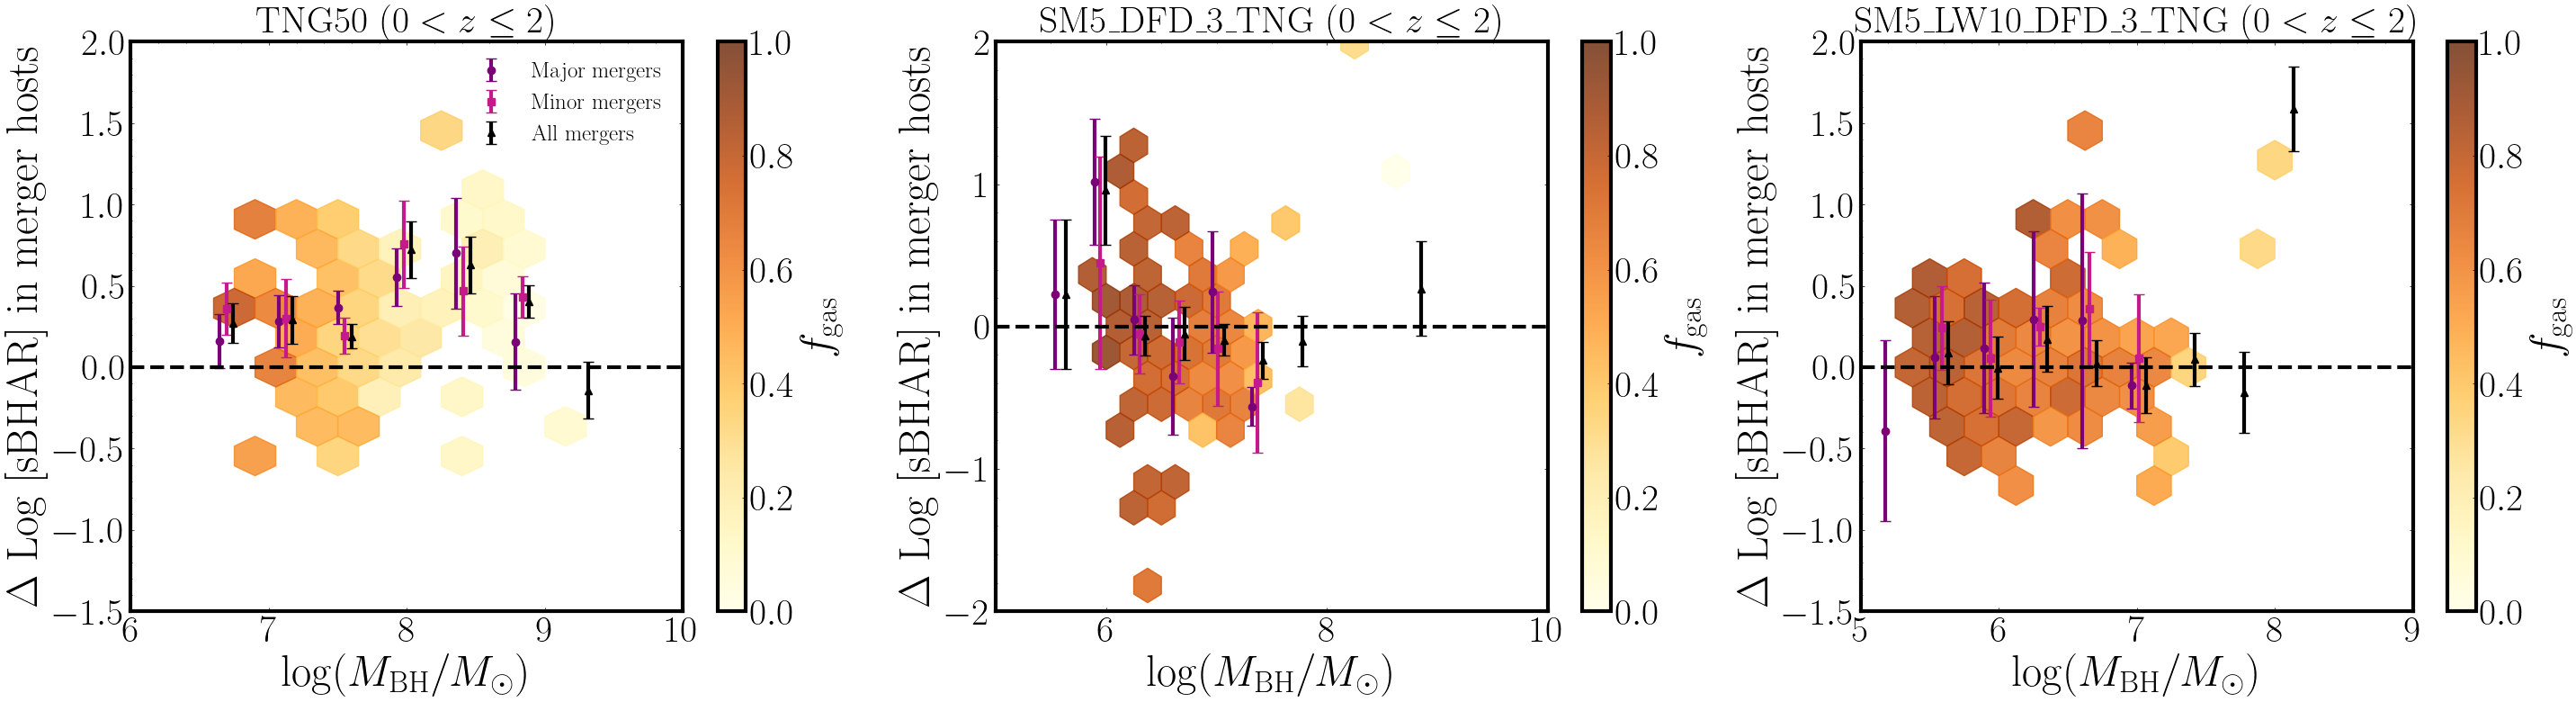

In [11]:
fig,ax = plt.subplots(1,3,figsize=(29,8))

log_MBH_bins = np.linspace(6,12,15)

sim='TNG50'
z_offset = 0.05
c_major = "#7a0177"   # purple
c_minor = "#c51b8a"   # pink
c_all   = "#000000"   # black
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[0] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[0], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[0].set_xlim(6,10)
ax[0].set_ylim(-1.5,2)
ax[0].legend()
ax[0].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_DFD_3_TNG'
log_MBH_bins = np.linspace(5,10,15)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[1] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[1], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=5, xmax=10, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(5,10)
ax[1].set_ylim(-2,2)
#ax[1].legend()
ax[1].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_LW10_DFD_3_TNG'
log_MBH_bins = np.linspace(5,10,15)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[2] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[2], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=8, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[2].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[2].axhline(0,ls='--',color='black')
ax[2].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[2].set_xlim(5,9)
ax[2].set_ylim(-1.5,2)
#ax[2].legend()
ax[2].set_title(f'{sim} ($0<z\leq2$)')

fig.tight_layout()
plt.show()

### sBHAR vs Merger time delays

In [12]:
def z_to_tlookback(z):
    """Convert redshift to lookback time in Gyr using Planck15 cosmology."""
    return Planck15.lookback_time(z).value  # returns time in Gyr

In [ ]:
def get_scale_factors(basePath, filename="output_scale_factors.txt"):
    path = basePath.split('/output')[0]
    #print(path)
    f = open(path+"/"+filename,'r')
    snaptimes = np.array([float(line) for line in f.readlines()])
    f.close()
    print(f"snapshot scale factors in {path}:")
    return snaptimes

In [38]:
TNG_scalefactors = get_scale_factors(TNG_basepath)
z = 1/TNG_scalefactors - 1                  
tlook_TNG = z_to_tlookback(z)
deltat_TNG = tlook_TNG[:-1]-tlook_TNG[1:]
snaps_TNG = np.arange(len(TNG_scalefactors))

snapshot scale factors in /orange/lblecha/IllustrisTNG/Runs/TNG50-1:
[0.04751386 0.06254232 0.07704034 0.08350282 0.09093728 0.09625777
 0.09997661 0.10582597 0.11096103 0.11634526 0.12141409 0.12491542
 0.13348287 0.14263794 0.1460576  0.15314485 0.16057599 0.1667797
 0.17653754 0.18422877 0.19316822 0.1996827  0.21236949 0.22267443
 0.2334794  0.24949284 0.25668768 0.26787083 0.2795412  0.29034102
 0.30155808 0.31172794 0.32224077 0.33310814 0.344342   0.35427208
 0.36448853 0.37499959 0.38398999 0.39506344 0.40071935 0.41423335
 0.42416436 0.43433346 0.44474635 0.45325613 0.46412269 0.47300321
 0.48205365 0.49127726 0.50067736 0.51268081 0.52002058 0.52997065
 0.54011111 0.55044559 0.55832602 0.56900902 0.57715521 0.5881985
 0.59661941 0.60803512 0.61674002 0.62556955 0.63452548 0.64666649
 0.65592445 0.66531496 0.6748399  0.68450121 0.69430083 0.70424076
 0.71432298 0.72454955 0.73492252 0.74192021 0.75254187 0.76331559
 0.77058363 0.78532797 0.7928056  0.80415576 0.81566841 0.8234

In [47]:
#for brahma 
snap,red = arepo.get_snapshot_redshift_correspondence(simPath)
brahma_tlook = z_to_tlookback(red)
brahma_deltat = brahma_tlook[:-1]-brahma_tlook[1:]


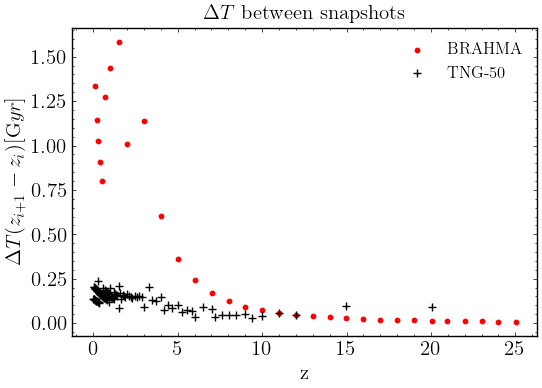

In [75]:
hostplot.set_plot_style(spinewidth=1, linewidth=1, titlesize=15, labelsize=15, xlabelsize=15, ylabelsize=15, legendsize=12, bold=True)
plt.figure(figsize=(6,4))
plt.scatter(red[:-1],brahma_deltat,marker="o",s=10,c="red",label="BRAHMA")
plt.scatter(z[:-1],deltat_TNG,marker="+",c="k",label="TNG-50")
#plt.axhline(1,color="k",linestyle="--")
#plt.xlim(0,5)
plt.xlabel("z")
plt.title("$\Delta T$ between snapshots")
plt.legend()
plt.ylabel("$\Delta T (z_{i+1} - z_{i}) [\mathrm Gyr]$")
plt.savefig("../../figures/Brahma_vs_TNG50_time_delay.pdf")

In [109]:
merger_time_delay = {}

for sim in sim_names:
    merger_time_delay[sim] = {'td':[], 'snap1':[], 'snap2':[], 'snap_f':[]}
    for i, z_prog in enumerate(sim_objs[sim].z_progs):
        z_post_merger = sim_objs[sim].z_merging_pop[i]
        if z_prog[0] != z_prog[1]:
            z_merger_time = min(z_prog[0], z_prog[1])
        else:
            z_merger_time = z_prog[0]
        tdelay = z_to_tlookback(z_merger_time) - z_to_tlookback(z_post_merger)
        
        # Get snapshot numbers
        snap1 = sim_objs[sim].snap_progs[i][0] if hasattr(sim_objs[sim], 'snap_progs') else None
        snap2 = sim_objs[sim].snap_progs[i][1] if hasattr(sim_objs[sim], 'snap_progs') else None
        snap_f = sim_objs[sim].snap_merging_pop[i] if hasattr(sim_objs[sim], 'snap_merging_pop') else None
        
        merger_time_delay[sim]['td'].append(tdelay)
        merger_time_delay[sim]['snap1'].append(snap1)
        merger_time_delay[sim]['snap2'].append(snap2)
        merger_time_delay[sim]['snap_f'].append(snap_f)

# Print summary statistics
print("Merger time delay statistics (in Gyr):")
print(f"{'Simulation':<30} {'Mean':<15} {'Std Dev':<15} {'Min':<15} {'Max':<15}")
for sim in sim_names:
    delays = np.array(merger_time_delay[sim]['td'])
    print(f"{sim:<30} {np.mean(delays):<15.3f} {np.std(delays):<15.3f} {np.min(delays):<15.3f} {np.max(delays):<15.3f}")

Merger time delay statistics (in Gyr):
Simulation                     Mean            Std Dev         Min             Max            
SM5_TNG                        0.993           0.425           0.092           1.585          
SM5_LW10_TNG                   0.954           0.446           0.092           1.585          
SM5_DFD_3_TNG                  1.046           0.402           0.092           1.585          
SM5_LW10_DFD_3_TNG             1.012           0.407           0.124           1.585          
SM5_LW10_LOWSPIN_TNG           0.909           0.446           0.072           1.585          
SM5_LW10_LOWSPIN_RICH_TNG      0.860           0.479           0.057           1.585          
TNG50                          0.159           0.027           0.065           0.236          


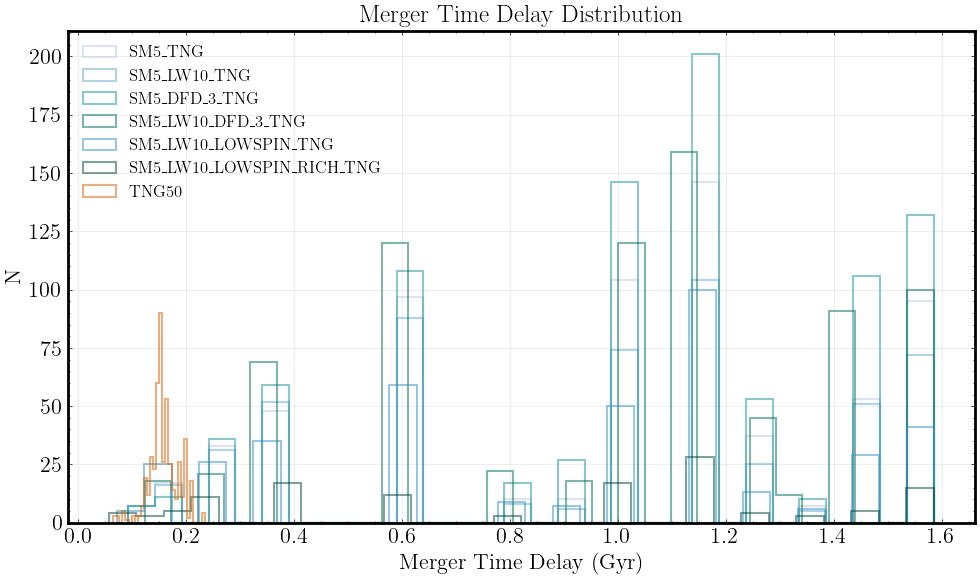

In [114]:
# Plot merger time delay histograms - all on same graph
fig, ax = plt.subplots(1, 1, figsize=(10,6))

hostplot.set_plot_style(spinewidth=2, linewidth=2, titlesize=20, labelsize=18, xlabelsize=16, ylabelsize=16, legendsize=12, bold=True)

# Plot histogram for each simulation on the same plot
for sim in sim_names:
    delays = np.array(merger_time_delay[sim]['td'])
    ax.hist(delays, bins=30, color=sim_colors[sim], alpha=0.5,histtype='step', linewidth=1.5, label=sim)

ax.set_xlabel('Merger Time Delay (Gyr)', fontsize=16)
ax.set_ylabel('N', fontsize=16)
ax.set_title('Merger Time Delay Distribution', fontsize=18, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### sBHAR vs merger time delay plots

In [131]:
merger_time_delay

{'SM5_TNG': {'td': [1.3363428020639425,
   1.3363428020639425,
   1.3363428020639425,
   1.3363428020639425,
   1.3363428020639425,
   1.3363428020639425,
   1.3363428020639425,
   1.1439644925643995,
   1.1439644925643995,
   1.1439644925643995,
   1.1439644925643995,
   1.1439644925643995,
   1.1439644925643995,
   1.1439644925643995,
   1.1439644925643995,
   1.023747990541119,
   1.023747990541119,
   1.023747990541119,
   1.023747990541119,
   1.023747990541119,
   1.023747990541119,
   1.023747990541119,
   0.9093989965181413,
   0.9093989965181413,
   0.9093989965181413,
   0.9093989965181413,
   0.9093989965181413,
   0.9093989965181413,
   0.9093989965181413,
   0.9093989965181413,
   0.9093989965181413,
   0.9093989965181413,
   0.802468648279838,
   0.802468648279838,
   0.802468648279838,
   0.802468648279838,
   0.802468648279838,
   0.802468648279838,
   0.802468648279838,
   0.802468648279838,
   0.802468648279838,
   0.802468648279838,
   1.2722752328817588,
   1.272275

In [152]:
def hexplot_mergertimedelays(ax,sim_name,quantity,zlow=0,zupper=2,gridsize=50,cmap='Blues',xmin=5,xmax=9,ymin=-2,ymax=2,mincnt=1,alpha=0.5,vmin=None,vmax=None):
    """Create a hexbin plot of merger time delays vs black hole mass."""
    
    sim_obj = sim_objs[sim_name]
    merger_z_mask = (sim_obj.z_merging_pop >= zlow) & (sim_obj.z_merging_pop < zupper)

    merging_pop_quantity = getattr(sim_obj,quantity+"_merging_pop")[merger_z_mask]
    control_pop_quantity = getattr(sim_obj,quantity+"_control_pop")[merger_z_mask]

    quantity_enhancement = merging_pop_quantity / control_pop_quantity
    MBH_mergers = np.log10(sim_obj.MBH_merging_pop[merger_z_mask])
    
    # Convert td list to array and apply mask
    td_array = np.array(merger_time_delay[sim_name]['td'])
    z = td_array[merger_z_mask]

    x = MBH_mergers
    y = np.log10(quantity_enhancement)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    z = z[valid]
    
    hb = ax.hexbin(x, y, C=z, gridsize=gridsize, reduce_C_function=np.nanmean,cmap=cmap,
                   extent=(xmin, xmax, ymin, ymax), mincnt=mincnt, alpha=alpha)
    plt.colorbar(hb, ax=ax, label='Tdelay(Gyr)')
    # ax.set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
    # ax.set_ylabel('Merger Time Delay (Gyr)')
    # ax.set_title(f'Merger Time Delay vs Black Hole Mass ({zlow} < z < {zupper})')

    return ax

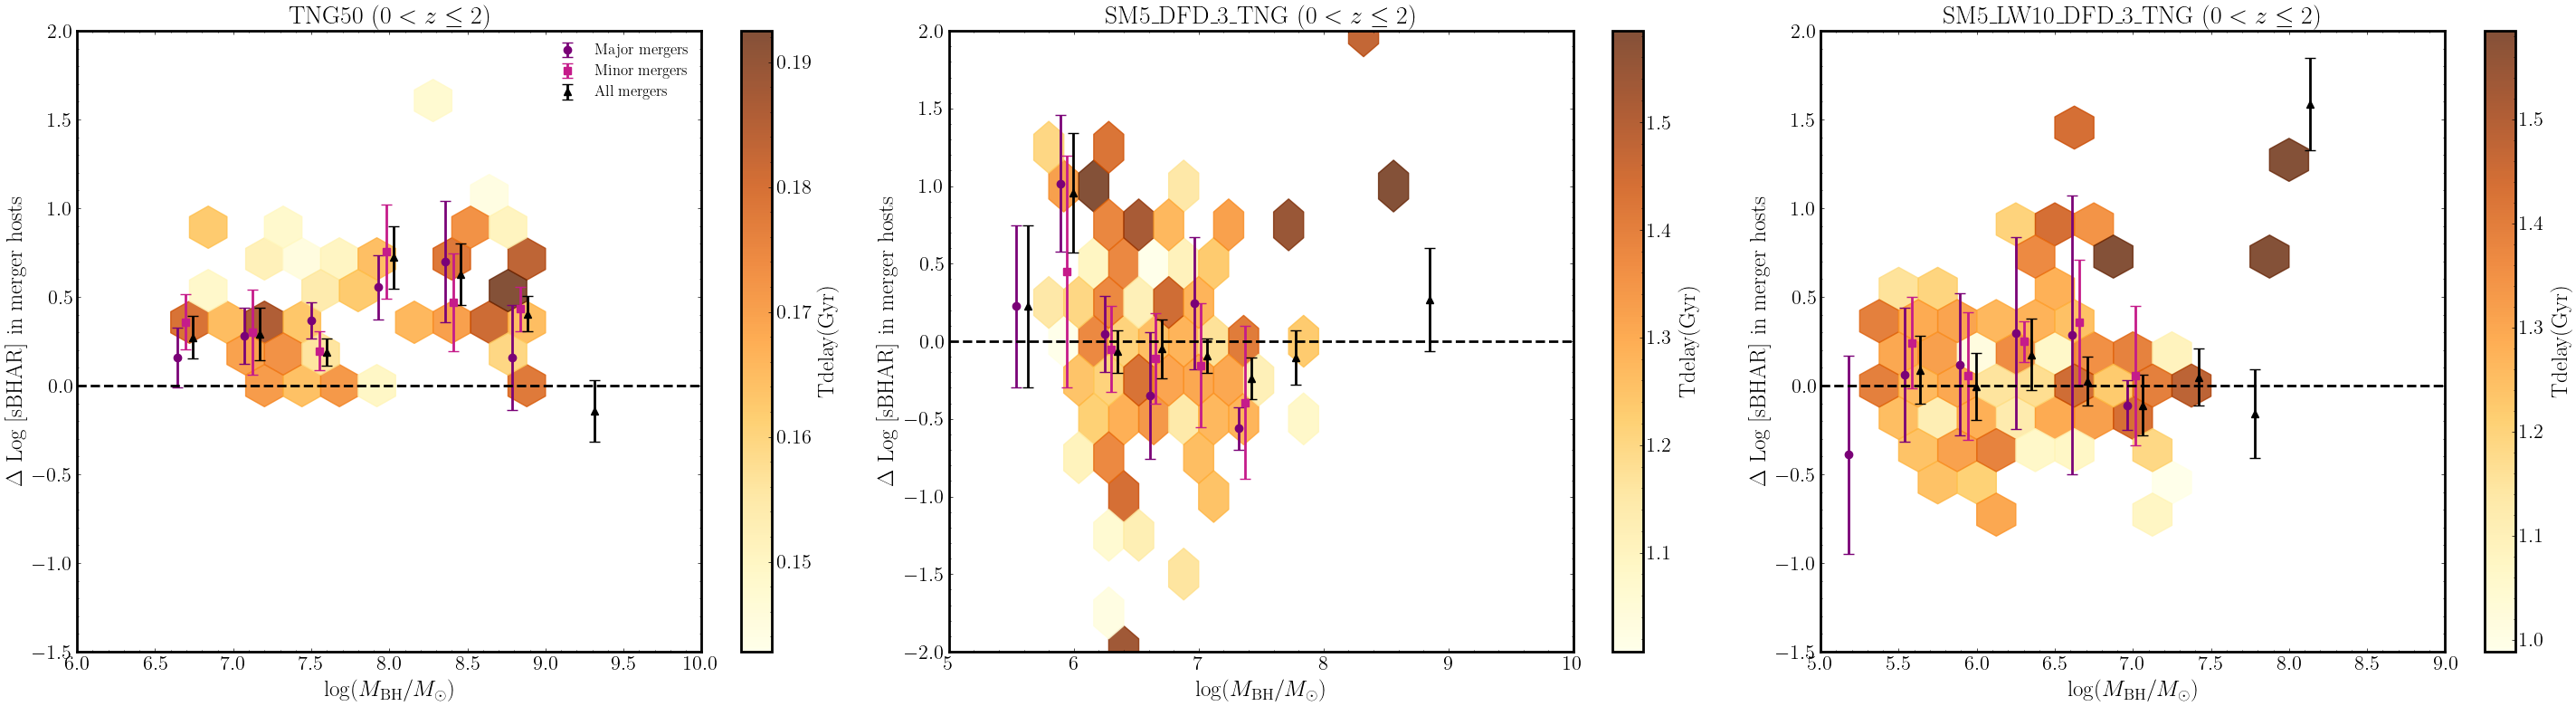

In [164]:
fig,ax = plt.subplots(1,3,figsize=(29,8))

log_MBH_bins = np.linspace(6,12,15)

sim='TNG50'
z_offset = 0.05
c_major = "#7a0177"   # purple
c_minor = "#c51b8a"   # pink
c_all   = "#000000"   # black
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[0] = hexplot_mergertimedelays(ax[0],sim,'sBHAR',zlow=0,zupper=2,gridsize=25,cmap='YlOrBr',xmin=6,xmax=12,ymin=0,ymax=5,mincnt=3,alpha=0.8,vmin=None,vmax=None)

ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[0].set_xlim(6,10)
ax[0].set_ylim(-1.5,2)
ax[0].legend()
ax[0].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_DFD_3_TNG'
log_MBH_bins = np.linspace(5,10,15)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[1] = hexplot_mergertimedelays(ax[1],sim,'sBHAR',zlow=0,zupper=2,gridsize=25,cmap='YlOrBr',xmin=4,xmax=10,ymin=-2,ymax=5,mincnt=3,alpha=0.8,vmin=None,vmax=None)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(5,10)
ax[1].set_ylim(-2,2)
#ax[1].legend()
ax[1].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_LW10_DFD_3_TNG'
log_MBH_bins = np.linspace(5,10,15)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[2] = hexplot_mergertimedelays(ax[2],sim,quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=8, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8,vmin=0,vmax=1
)

ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[2].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[2].axhline(0,ls='--',color='black')
ax[2].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[2].set_xlim(5,9)
ax[2].set_ylim(-1.5,2)
#ax[2].legend()
ax[2].set_title(f'{sim} ($0<z\leq2$)')

ax[2].set_title(f'{sim} ($0<z\leq2$)')

fig.tight_layout()
plt.show()

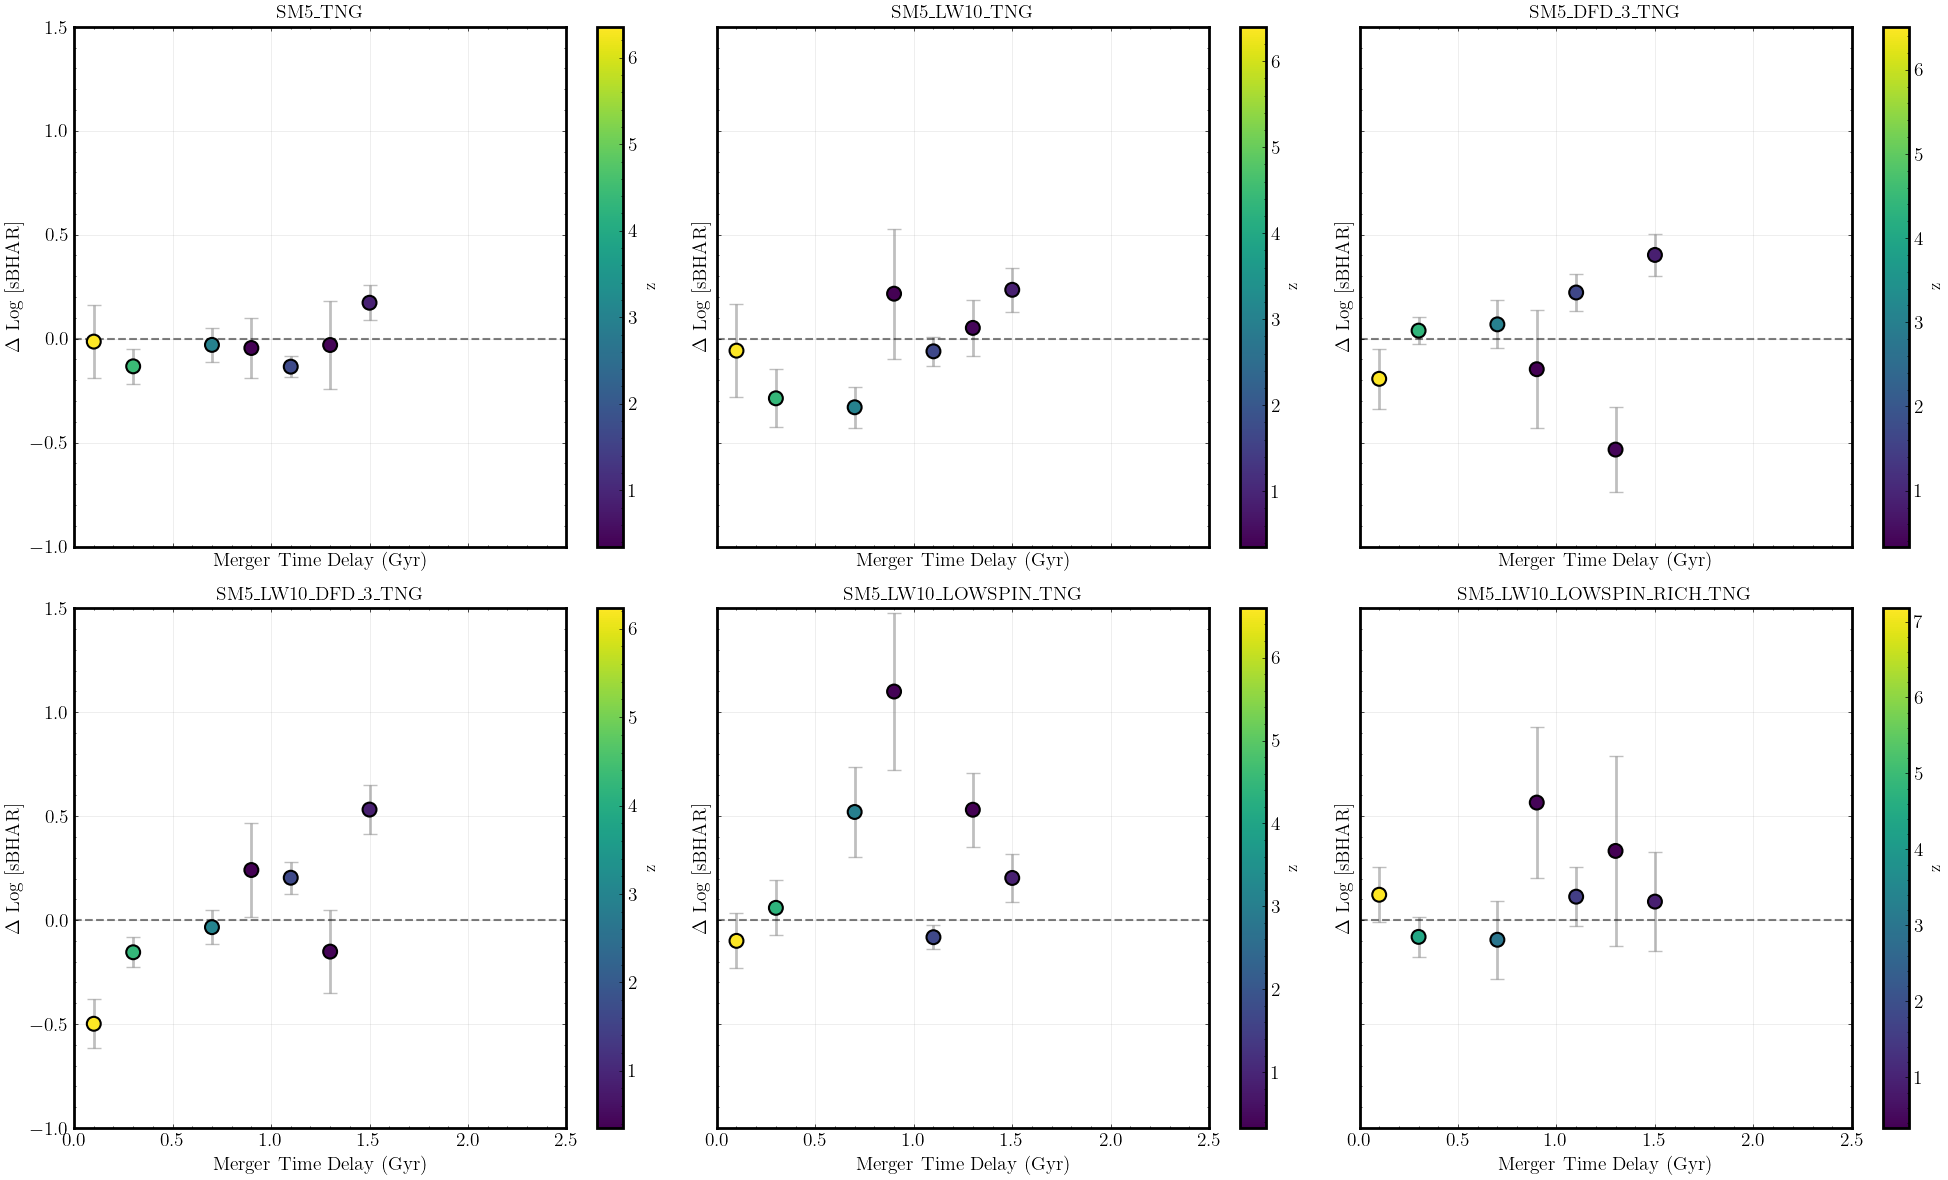

In [167]:
# Plot log sBHAR vs merger time delay for BRAHMA simulations, binned by time delay
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

hostplot.set_plot_style(spinewidth=2, linewidth=2, titlesize=16, labelsize=14, 
                        xlabelsize=14, ylabelsize=14, legendsize=10, bold=True)

# Define time delay bins
td_bins = np.arange(0, 2.5, 0.2)  # Bins from 0 to 2.5 Gyr with 0.2 Gyr width

for idx, sim in enumerate(brahma_simName_array):
    ax = axes[idx]
    sim_obj = sim_objs[sim]
    
    # Get sBHAR for merging and control populations
    sBHAR_merging = sim_obj.sBHAR_merging_pop
    sBHAR_control = sim_obj.sBHAR_control_pop
    
    # Calculate log sBHAR enhancement
    log_sBHAR_enhancement = []
    merger_td = []
    redshifts_plot = []
    
    for i in range(len(sBHAR_merging)):
        if sBHAR_merging[i] > 0 and sBHAR_control[i] > 0:
            log_enh = np.log10(sBHAR_merging[i]) - np.log10(sBHAR_control[i])
            log_sBHAR_enhancement.append(log_enh)
            merger_td.append(merger_time_delay[sim]['td'][i])
            redshifts_plot.append(sim_obj.z_merging_pop[i])
    
    log_sBHAR_enhancement = np.array(log_sBHAR_enhancement)
    merger_td = np.array(merger_td)
    redshifts_plot = np.array(redshifts_plot)
    
    # Bin the data by time delay
    td_bin_centers = []
    mean_log_sBHAR = []
    std_log_sBHAR = []
    mean_redshift = []
    
    for i in range(len(td_bins) - 1):
        bin_mask = (merger_td >= td_bins[i]) & (merger_td < td_bins[i+1])
        if np.sum(bin_mask) > 0:
            td_bin_centers.append((td_bins[i] + td_bins[i+1]) / 2)
            mean_log_sBHAR.append(np.mean(log_sBHAR_enhancement[bin_mask]))
            std_log_sBHAR.append(stats.sem(log_sBHAR_enhancement[bin_mask]))
            mean_redshift.append(np.mean(redshifts_plot[bin_mask]))
    
    td_bin_centers = np.array(td_bin_centers)
    mean_log_sBHAR = np.array(mean_log_sBHAR)
    std_log_sBHAR = np.array(std_log_sBHAR)
    mean_redshift = np.array(mean_redshift)
    
    # Plot binned data with error bars, color-coded by mean redshift
    scatter = ax.scatter(td_bin_centers, mean_log_sBHAR, c=mean_redshift, 
                        cmap='viridis', s=100, edgecolors='black', linewidth=1.5, zorder=3)
    ax.errorbar(td_bin_centers, mean_log_sBHAR, yerr=std_log_sBHAR, 
                fmt='none', ecolor='gray', alpha=0.5, capsize=5, zorder=2)
    
    # Add colorbar for each subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('z', fontsize=12)
    
    # Add reference line at y=0
    ax.axhline(0, ls='--', color='black', alpha=0.5, linewidth=1.5)
    
    # Labels and title
    ax.set_xlabel('Merger Time Delay (Gyr)', fontsize=14)
    ax.set_ylabel('$\Delta$ Log [sBHAR]', fontsize=14)
    ax.set_title(f'{sim}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-1, 1.5)

fig.tight_layout()
plt.show()

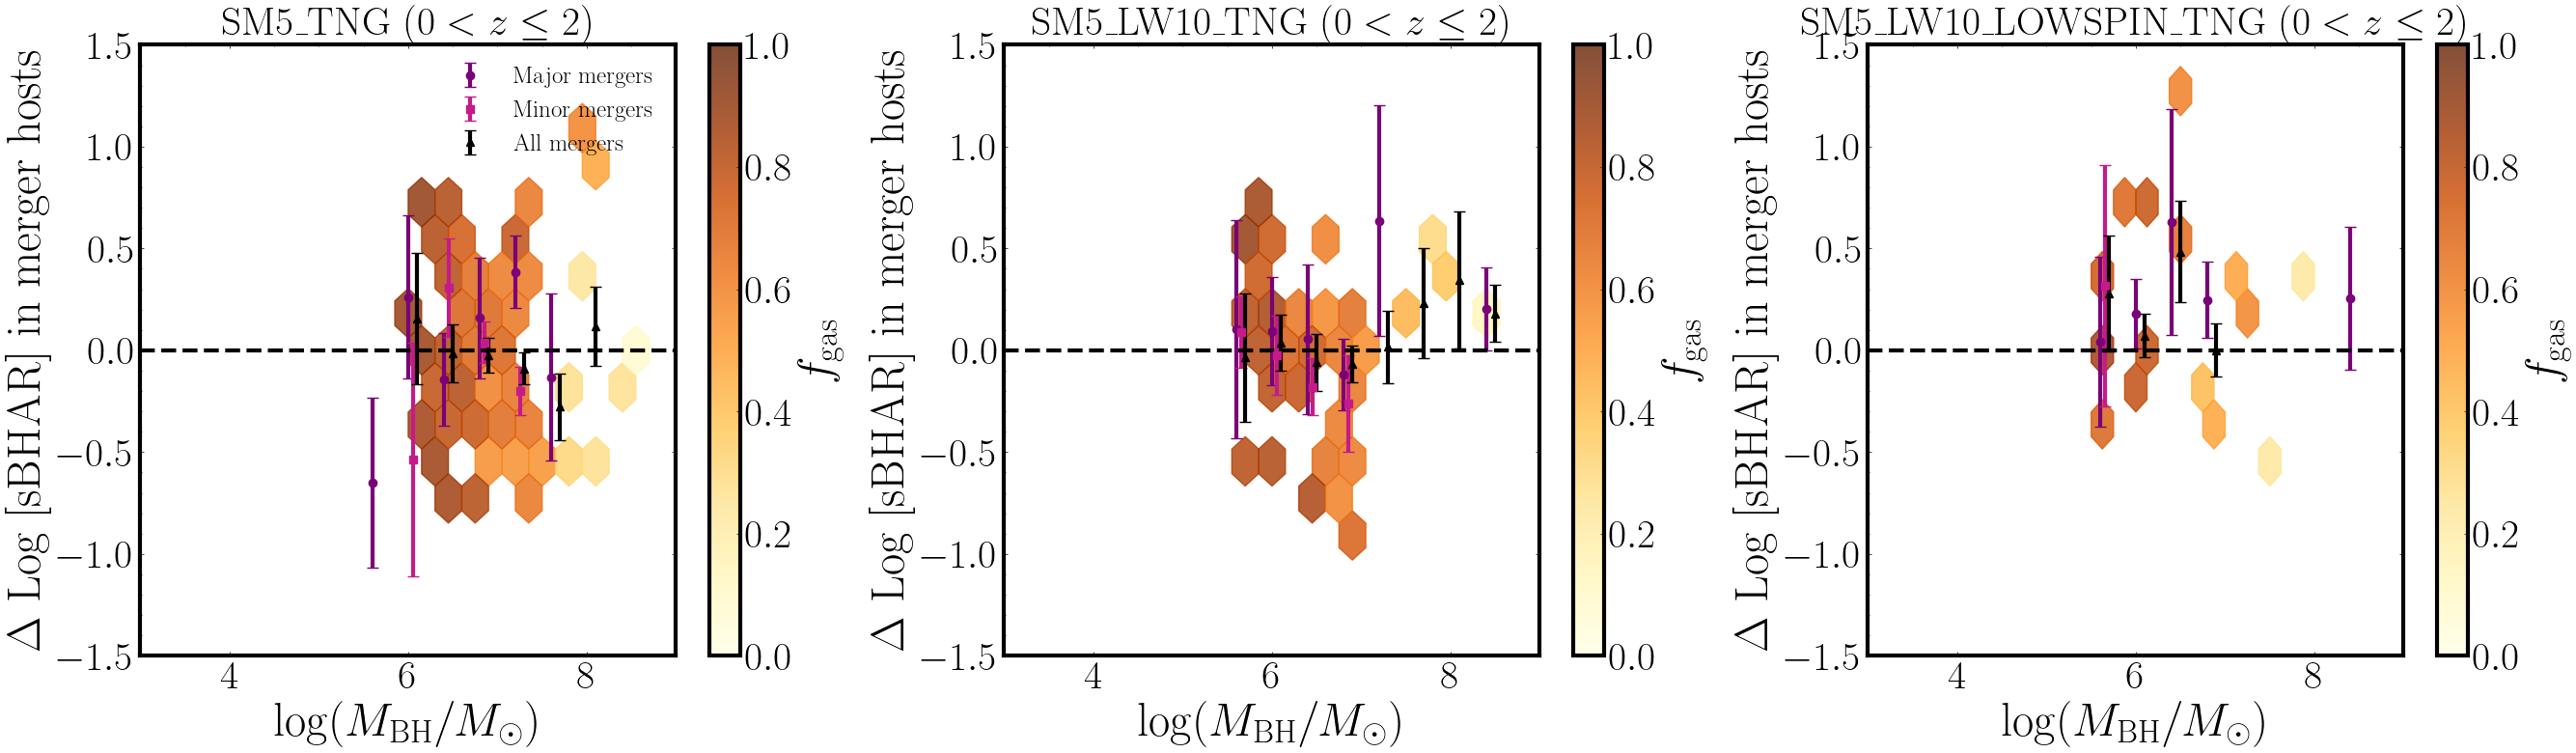

In [9]:
fig,ax = plt.subplots(1,3,figsize=(27,8))

sim='SM5_TNG'
log_MBH_bins = np.arange(3,9,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[0] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[0], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=9, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[0].set_xlim(3,9)
ax[0].set_ylim(-1.5,1.5)
ax[0].legend()
ax[0].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_LW10_TNG'
log_MBH_bins = np.arange(3,9,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[1] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[1], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=9, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(3,9)
ax[1].set_ylim(-1.5,1.5)
#ax[1].legend()
ax[1].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_LW10_LOWSPIN_TNG'
log_MBH_bins = np.arange(3,9,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=5)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=10)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=20)

ax[2] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[2], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=8, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[2].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[2].axhline(0,ls='--',color='black')
ax[2].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[2].set_xlim(3,9)
ax[2].set_ylim(-1.5,1.5)
#ax[2].legend()
ax[2].set_title(f'{sim} ($0<z\leq2$)')

fig.tight_layout()
plt.show()

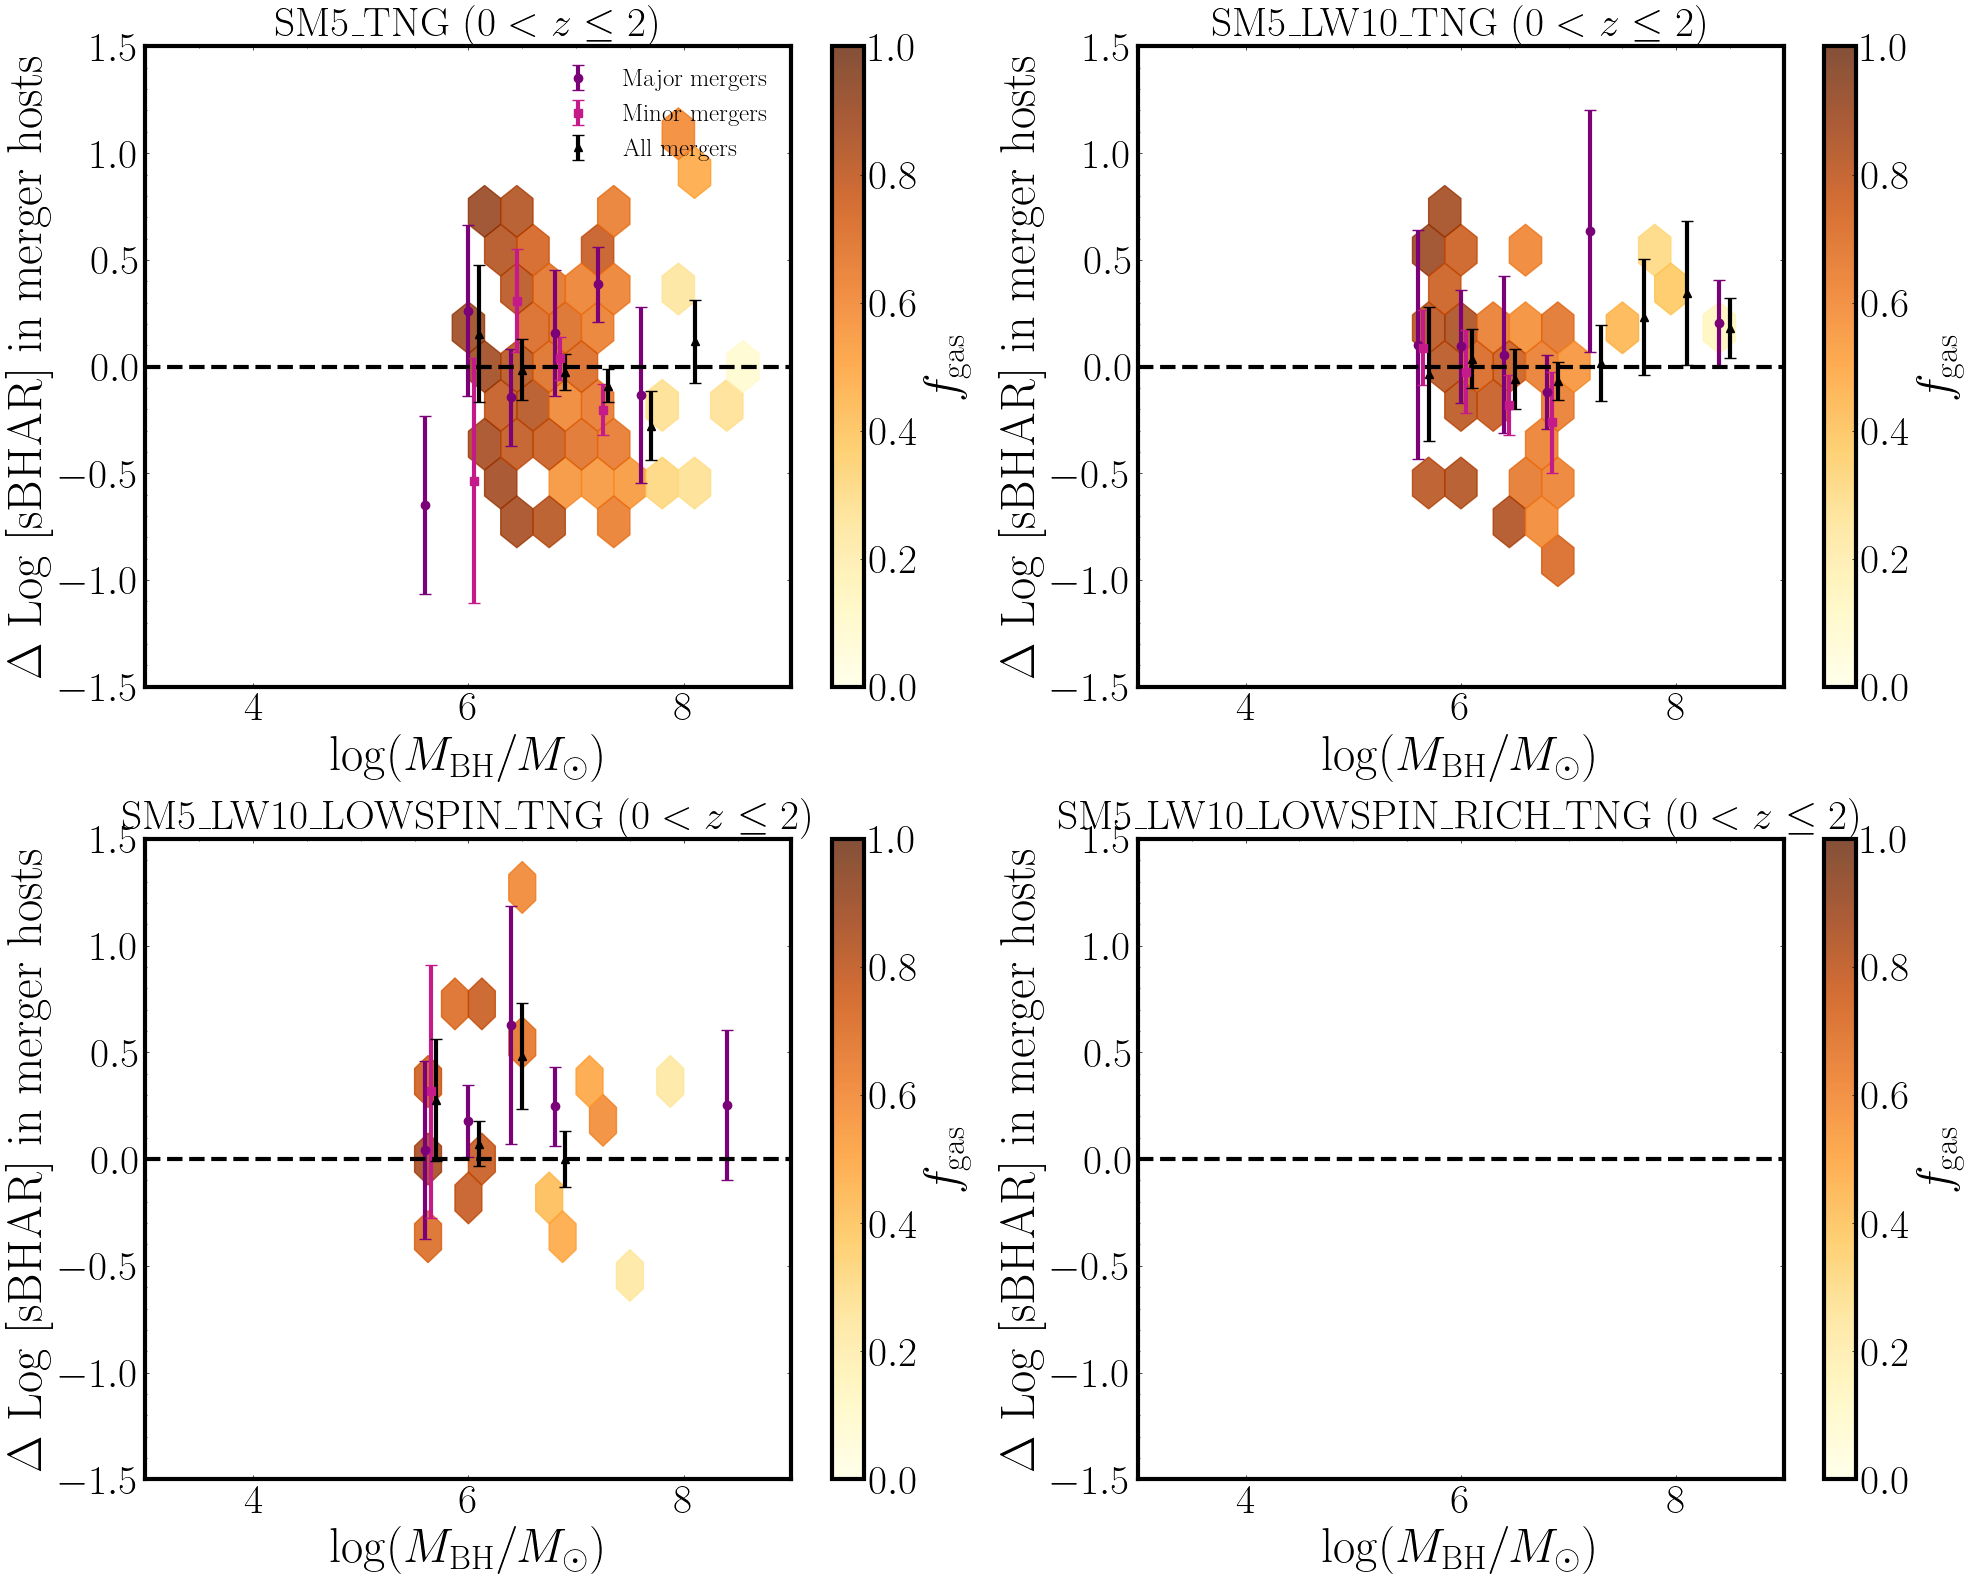

In [33]:
fig,ax = plt.subplots(2,2,figsize=(20,16))
ax = ax.flatten()

sim='SM5_TNG'
log_MBH_bins = np.arange(3,9,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[0] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[0], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=9, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[0].set_xlim(3,9)
ax[0].set_ylim(-1.5,1.5)
ax[0].legend()
ax[0].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_LW10_TNG'
log_MBH_bins = np.arange(3,9,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[1] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[1], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=9, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(3,9)
ax[1].set_ylim(-1.5,1.5)
#ax[1].legend()
ax[1].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_LW10_LOWSPIN_TNG'
log_MBH_bins = np.arange(3,9,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=5)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=10)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=20)

ax[2] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[2], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=8, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[2].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[2].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[2].axhline(0,ls='--',color='black')
ax[2].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[2].set_xlim(3,9)
ax[2].set_ylim(-1.5,1.5)
#ax[2].legend()
ax[2].set_title(f'{sim} ($0<z\leq2$)')

sim='SM5_LW10_LOWSPIN_RICH_TNG'
log_MBH_bins = np.arange(3,9,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=5)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=10)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mbh_for_z(ax,sim_objs[sim],'sBHAR',10**log_MBH_bins,zlow=0,zupper=2,log=True,min_N=20)

ax[3] = util.make_hex_plot_quantity_vs_black_hole_mass(
    ax[3], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=3, xmax=8, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[3].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[3].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[3].errorbar(log_MBH_bins[:-1]+np.diff(log_MBH_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[3].set_xlabel(r'$\log(M_{\rm BH}/M_{\odot})$')
ax[3].axhline(0,ls='--',color='black')
ax[3].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[3].set_xlim(3,9)
ax[3].set_ylim(-1.5,1.5)
#ax[3].legend()
ax[3].set_title(f'{sim} ($0<z\leq2$)')

fig.tight_layout()
plt.show()

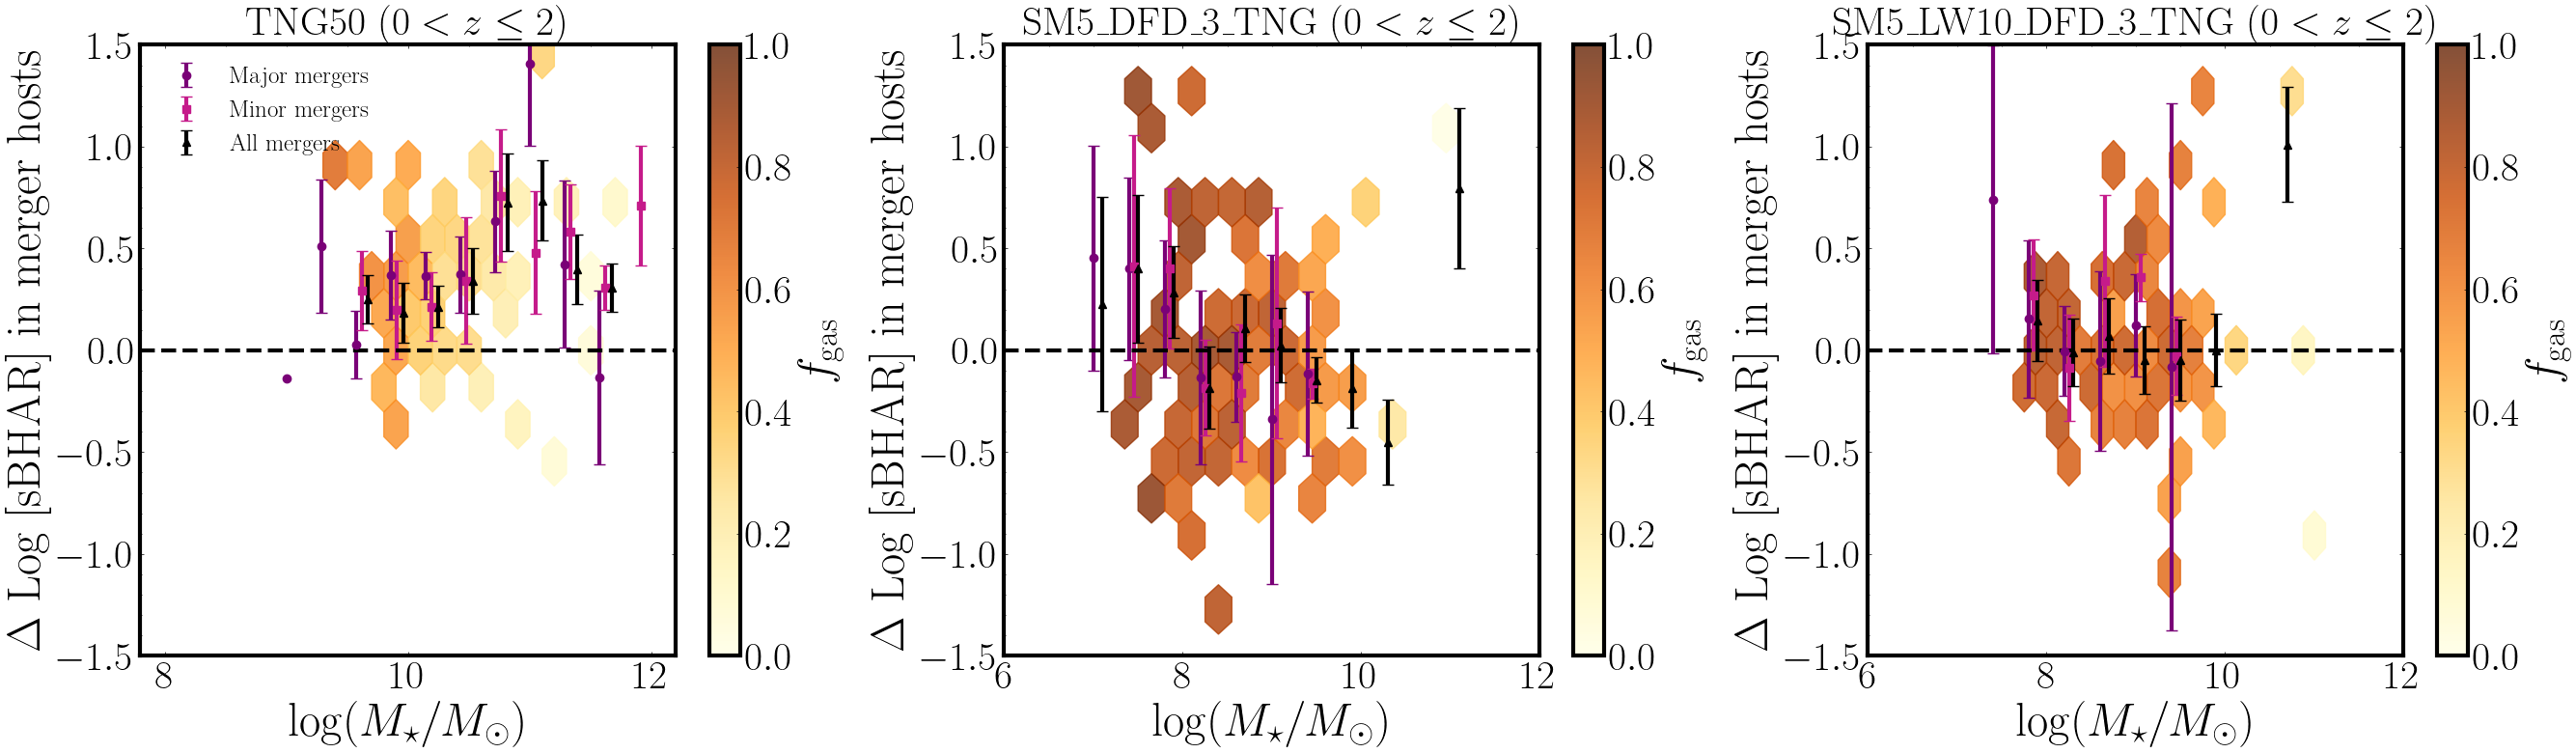

In [16]:
fig,ax = plt.subplots(1,3,figsize=(27,8))

log_Mstar_bins = np.linspace(8,12,15)

sim='TNG50'
z_offset = 0.05
c_major = "#7a0177"   # purple
c_minor = "#c51b8a"   # pink
c_all   = "#000000"   # black
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[0] = util.make_hex_plot_quantity_vs_stellar_mass(
    ax[0], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=8, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[0].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[0].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[0].axhline(0,ls='--',color='black')
ax[0].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
#ax[0].set_xlim(9,12)
ax[0].set_ylim(-1.5,1.5)
ax[0].legend()
ax[0].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_DFD_3_TNG'
log_Mstar_bins = np.arange(6,12,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=4)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=6)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=10)

ax[1] = util.make_hex_plot_quantity_vs_stellar_mass(
    ax[1], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=12, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[1].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[1].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[1].axhline(0,ls='--',color='black')
ax[1].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[1].set_xlim(6,12)
ax[1].set_ylim(-1.5,1.5)
#ax[1].legend()
ax[1].set_title(f'{sim} ($0<z\leq2)$')

sim='SM5_LW10_DFD_3_TNG'
log_Mstar_bins = np.arange(6,12,0.4)
z_offset = 0.05
c_major = "#7a0177"   
c_minor = "#c51b8a"   
c_all   = "#000000"   
avg_sBHAR_major,std_sBHAR_major = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,major_merger_flag=True,min_N=5)
avg_sBHAR_minor,std_sBHAR_minor = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,minor_merger_flag=True,min_N=10)
avg_sBHAR_all,std_sBHAR_all = util.enhancement_vs_mstar_for_z(ax,sim_objs[sim],'sBHAR',10**log_Mstar_bins,zlow=0,zupper=2,log=True,min_N=20)

ax[2] = util.make_hex_plot_quantity_vs_stellar_mass(
    ax[2], sim_objs[sim], quantity='sBHAR', zlow=0, zupper=2,
    gridsize=20, cmap='YlOrBr', xmin=6, xmax=11, ymin=-2, ymax=2,
    mincnt=3, alpha=0.8, color_quantity='fgas',vmin=0,vmax=1
)

ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2,     avg_sBHAR_major, yerr=std_sBHAR_major, fmt='o', capsize=4, label='Major mergers', color=c_major, alpha=1)
ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+z_offset, avg_sBHAR_minor, yerr=std_sBHAR_minor, fmt='s', capsize=4, label='Minor mergers', color=c_minor, alpha=1)
ax[2].errorbar(log_Mstar_bins[:-1]+np.diff(log_Mstar_bins)/2+2*z_offset, avg_sBHAR_all, yerr=std_sBHAR_all, fmt='^', capsize=4, label='All mergers', color=c_all, alpha=1)
ax[2].set_xlabel(r'$\log(M_{\star}/M_{\odot})$')
ax[2].axhline(0,ls='--',color='black')
ax[2].set_ylabel('$\Delta$ Log [sBHAR] in merger hosts')
ax[2].set_xlim(6,12)
ax[2].set_ylim(-1.5,1.5)
#ax[2].legend()
ax[2].set_title(f'{sim} ($0<z\leq2$)')

fig.tight_layout()
plt.show()

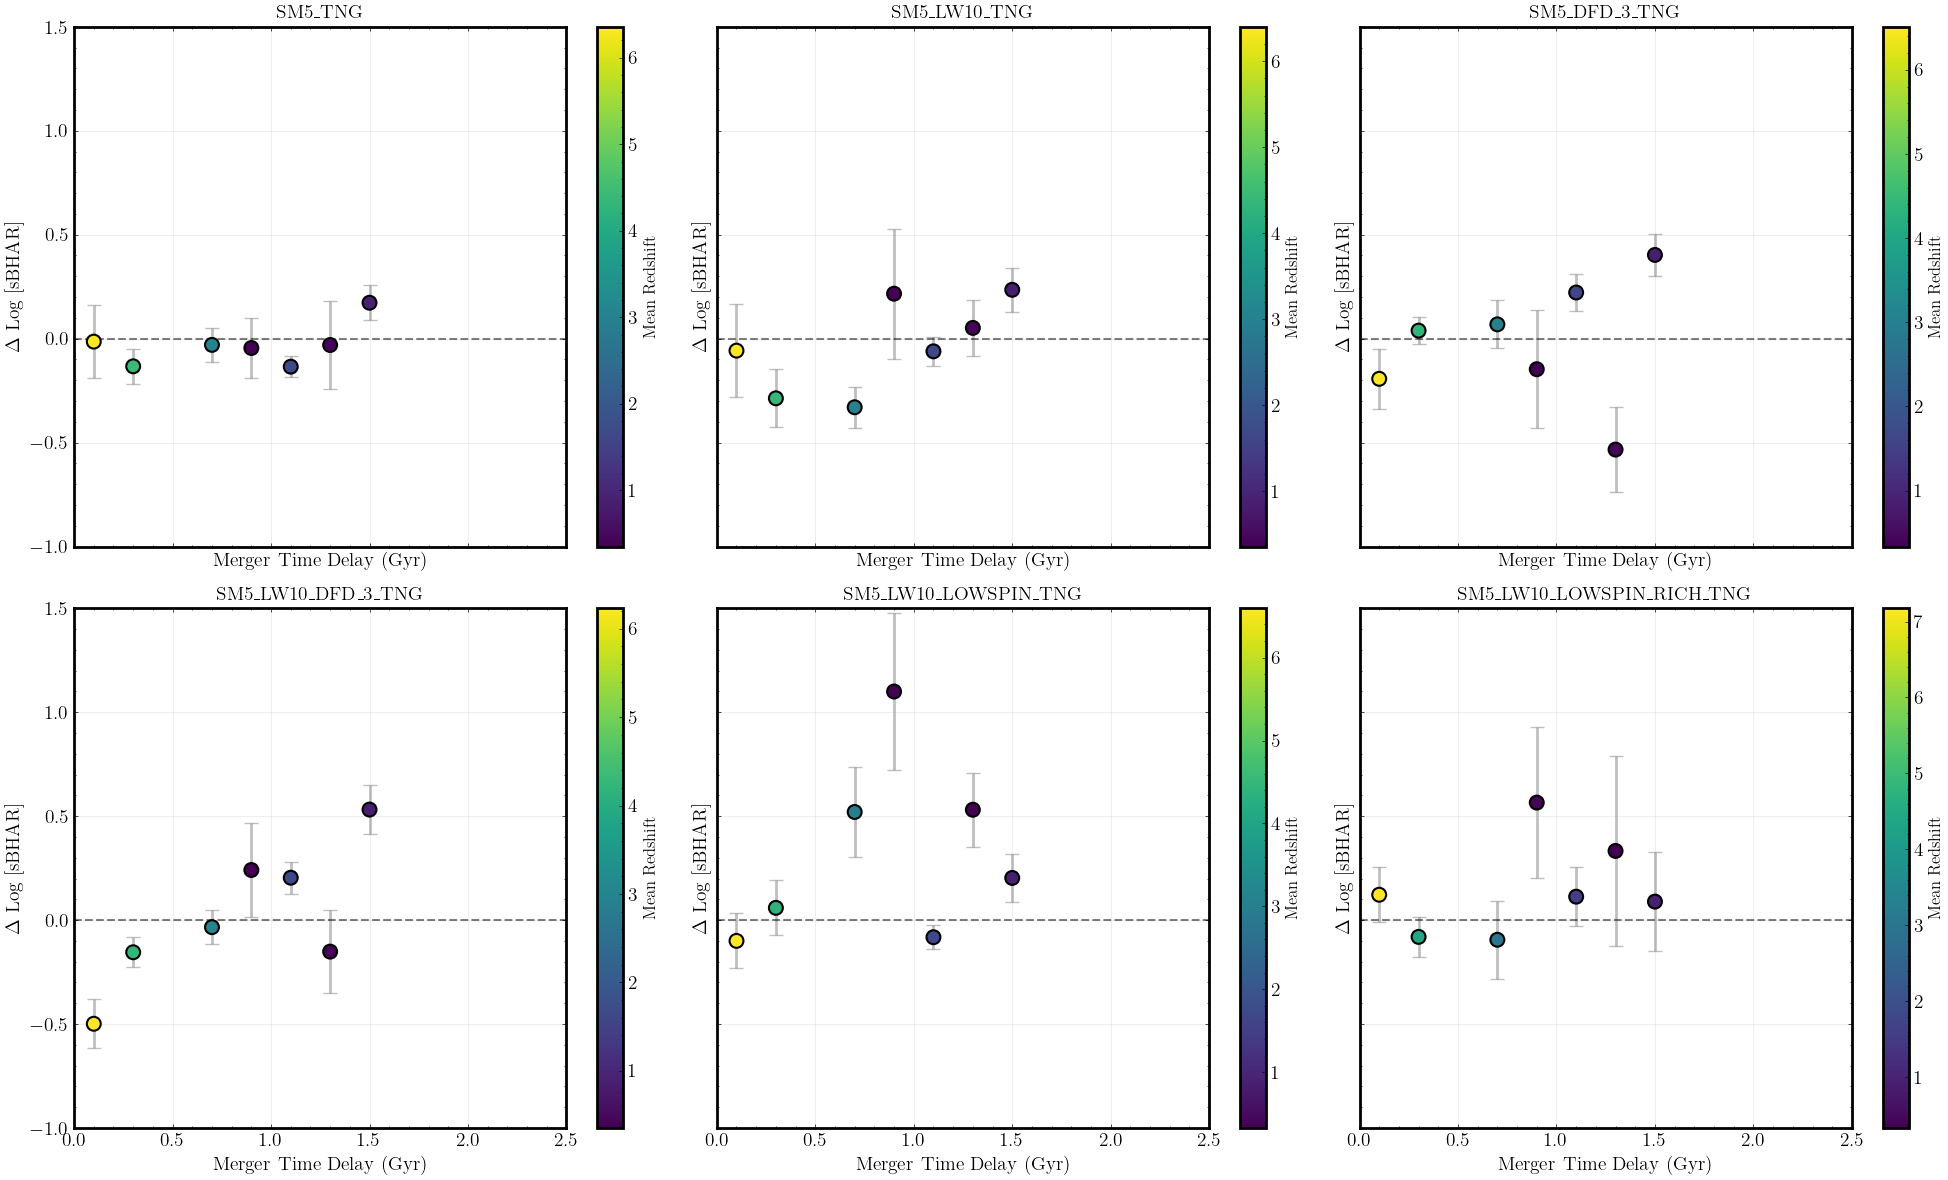

In [169]:
# Plot log sBHAR vs merger time delay for BRAHMA simulations, binned by time delay (restores sBHAR plot)
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

hostplot.set_plot_style(spinewidth=2, linewidth=2, titlesize=16, labelsize=14, 
                        xlabelsize=14, ylabelsize=14, legendsize=10, bold=True)

# Define time delay bins
td_bins = np.arange(0, 2.5, 0.2)  # Bins from 0 to 2.5 Gyr with 0.2 Gyr width

for idx, sim in enumerate(brahma_simName_array):
    ax = axes[idx]
    sim_obj = sim_objs[sim]
    
    # Get sBHAR for merging and control populations
    sBHAR_merging = sim_obj.sBHAR_merging_pop
    sBHAR_control = sim_obj.sBHAR_control_pop
    
    # Calculate log sBHAR enhancement
    log_sBHAR_enhancement = []
    merger_td = []
    redshifts_plot = []
    
    for i in range(len(sBHAR_merging)):
        if sBHAR_merging[i] > 0 and sBHAR_control[i] > 0:
            log_enh = np.log10(sBHAR_merging[i]) - np.log10(sBHAR_control[i])
            log_sBHAR_enhancement.append(log_enh)
            merger_td.append(merger_time_delay[sim]['td'][i])
            redshifts_plot.append(sim_obj.z_merging_pop[i])
    
    log_sBHAR_enhancement = np.array(log_sBHAR_enhancement)
    merger_td = np.array(merger_td)
    redshifts_plot = np.array(redshifts_plot)
    
    # Bin the data by time delay
    td_bin_centers = []
    mean_log_sBHAR = []
    std_log_sBHAR = []
    mean_redshift = []
    
    for i in range(len(td_bins) - 1):
        bin_mask = (merger_td >= td_bins[i]) & (merger_td < td_bins[i+1])
        if np.sum(bin_mask) > 0:
            td_bin_centers.append((td_bins[i] + td_bins[i+1]) / 2)
            mean_log_sBHAR.append(np.mean(log_sBHAR_enhancement[bin_mask]))
            std_log_sBHAR.append(stats.sem(log_sBHAR_enhancement[bin_mask]))
            mean_redshift.append(np.mean(redshifts_plot[bin_mask]))
    
    td_bin_centers = np.array(td_bin_centers)
    mean_log_sBHAR = np.array(mean_log_sBHAR)
    std_log_sBHAR = np.array(std_log_sBHAR)
    mean_redshift = np.array(mean_redshift)
    
    # Plot binned data with error bars, color-coded by mean redshift
    scatter = ax.scatter(td_bin_centers, mean_log_sBHAR, c=mean_redshift, 
                        cmap='viridis', s=100, edgecolors='black', linewidth=1.5, zorder=3)
    ax.errorbar(td_bin_centers, mean_log_sBHAR, yerr=std_log_sBHAR, 
                fmt='none', ecolor='gray', alpha=0.5, capsize=5, zorder=2)
    
    # Add colorbar for each subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Mean Redshift', fontsize=12)
    
    # Add reference line at y=0
    ax.axhline(0, ls='--', color='black', alpha=0.5, linewidth=1.5)
    
    # Labels and title
    ax.set_xlabel('Merger Time Delay (Gyr)', fontsize=14)
    ax.set_ylabel('$\Delta$ Log [sBHAR]', fontsize=14)
    ax.set_title(f'{sim}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-1, 1.5)

fig.tight_layout()
plt.show()

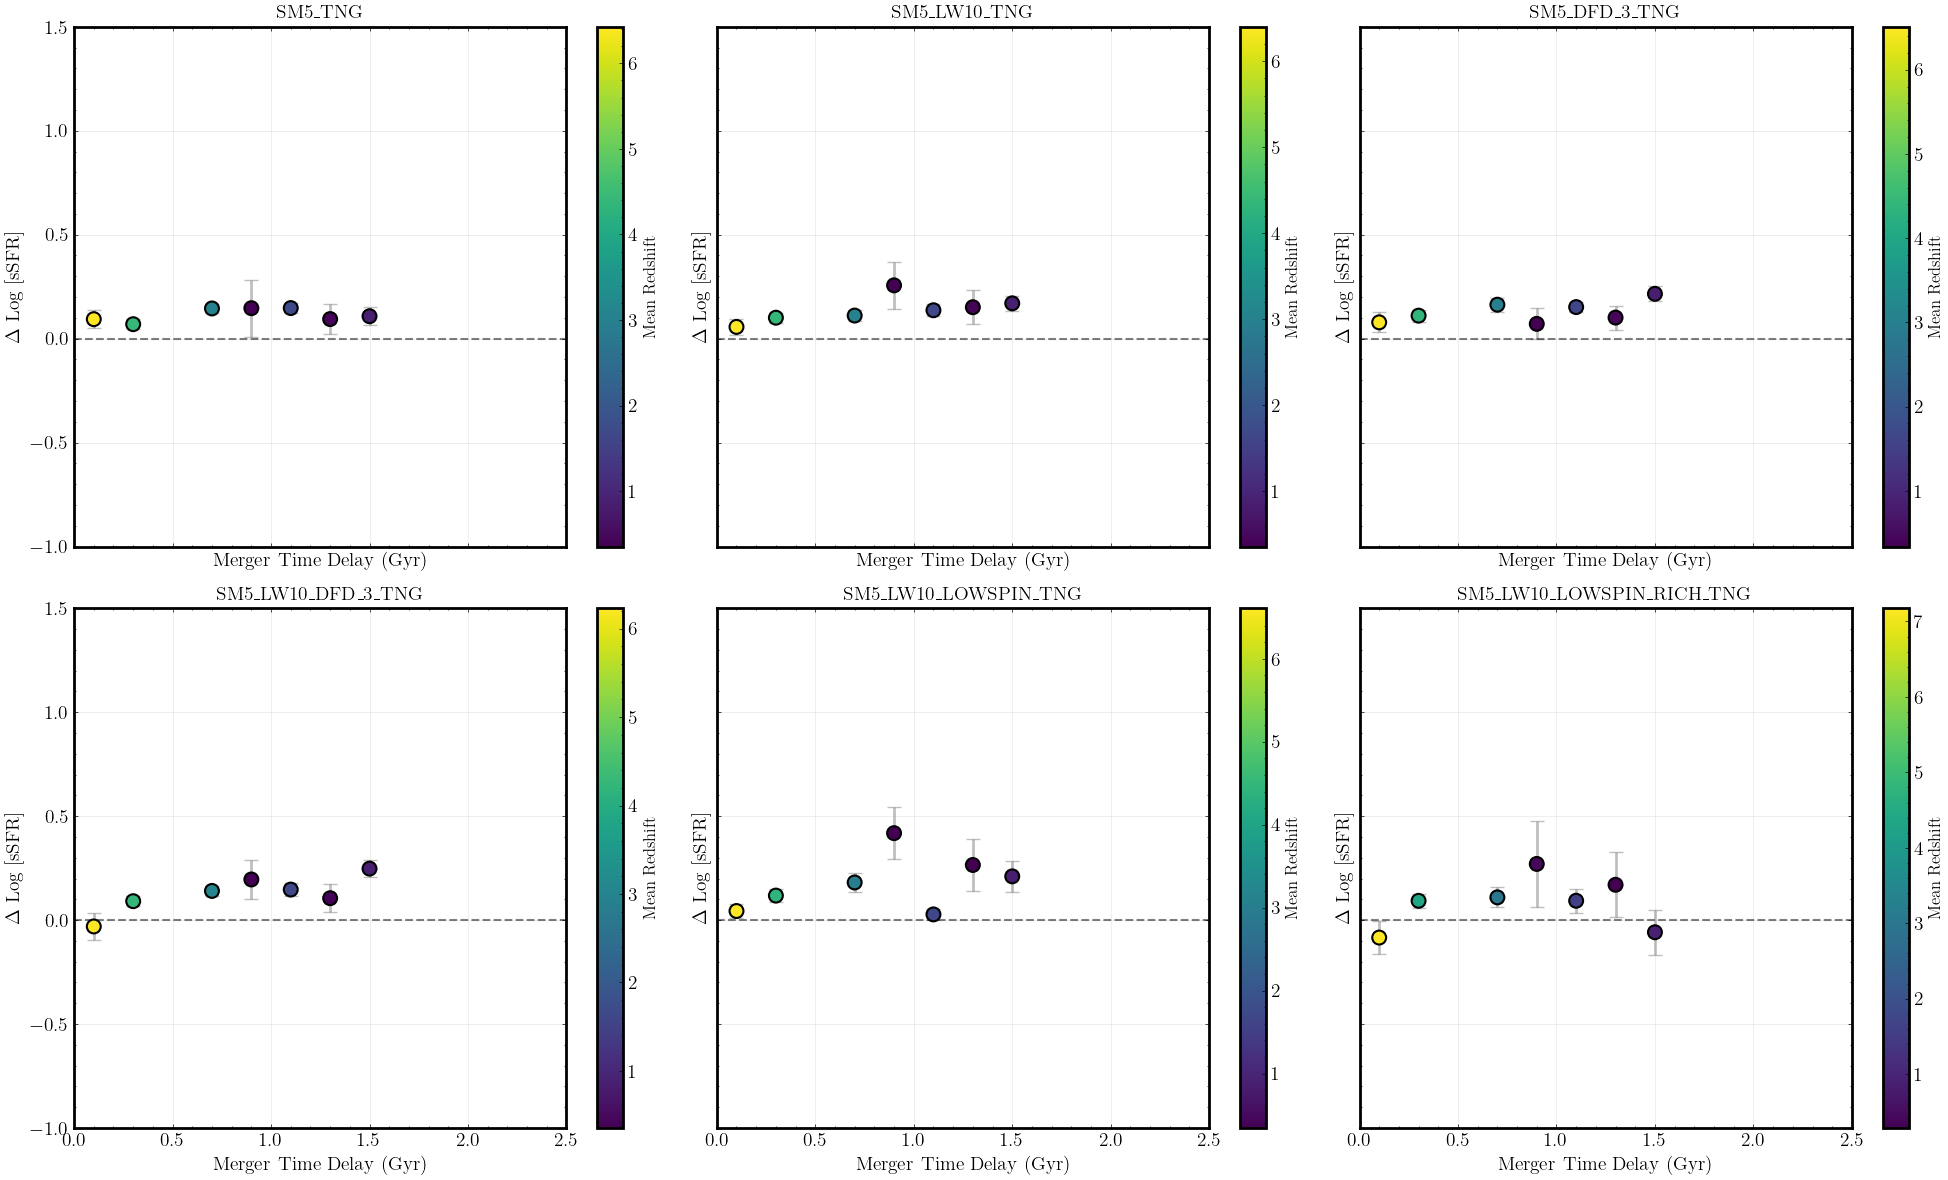

In [170]:
# Plot log sSFR vs merger time delay for BRAHMA simulations, binned by time delay (sSFR plot)
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

hostplot.set_plot_style(spinewidth=2, linewidth=2, titlesize=16, labelsize=14, 
                        xlabelsize=14, ylabelsize=14, legendsize=10, bold=True)

# Define time delay bins
td_bins = np.arange(0, 2.5, 0.2)  # Bins from 0 to 2.5 Gyr with 0.2 Gyr width

for idx, sim in enumerate(brahma_simName_array):
    ax = axes[idx]
    sim_obj = sim_objs[sim]
    
    # Get sSFR for merging and control populations
    sSFR_merging = sim_obj.sSFR_merging_pop
    sSFR_control = sim_obj.sSFR_control_pop
    
    # Calculate log sSFR enhancement
    log_sSFR_enhancement = []
    merger_td = []
    redshifts_plot = []
    
    for i in range(len(sSFR_merging)):
        if sSFR_merging[i] > 0 and sSFR_control[i] > 0:
            log_enh = np.log10(sSFR_merging[i]) - np.log10(sSFR_control[i])
            log_sSFR_enhancement.append(log_enh)
            merger_td.append(merger_time_delay[sim]['td'][i])
            redshifts_plot.append(sim_obj.z_merging_pop[i])
    
    log_sSFR_enhancement = np.array(log_sSFR_enhancement)
    merger_td = np.array(merger_td)
    redshifts_plot = np.array(redshifts_plot)
    
    # Bin the data by time delay
    td_bin_centers = []
    mean_log_sSFR = []
    std_log_sSFR = []
    mean_redshift = []
    
    for i in range(len(td_bins) - 1):
        bin_mask = (merger_td >= td_bins[i]) & (merger_td < td_bins[i+1])
        if np.sum(bin_mask) > 0:
            td_bin_centers.append((td_bins[i] + td_bins[i+1]) / 2)
            mean_log_sSFR.append(np.mean(log_sSFR_enhancement[bin_mask]))
            std_log_sSFR.append(stats.sem(log_sSFR_enhancement[bin_mask]))
            mean_redshift.append(np.mean(redshifts_plot[bin_mask]))
    
    td_bin_centers = np.array(td_bin_centers)
    mean_log_sSFR = np.array(mean_log_sSFR)
    std_log_sSFR = np.array(std_log_sSFR)
    mean_redshift = np.array(mean_redshift)
    
    # Plot binned data with error bars, color-coded by mean redshift
    scatter = ax.scatter(td_bin_centers, mean_log_sSFR, c=mean_redshift, 
                        cmap='viridis', s=100, edgecolors='black', linewidth=1.5, zorder=3)
    ax.errorbar(td_bin_centers, mean_log_sSFR, yerr=std_log_sSFR, 
                fmt='none', ecolor='gray', alpha=0.5, capsize=5, zorder=2)
    
    # Add colorbar for each subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Mean Redshift', fontsize=12)
    
    # Add reference line at y=0
    ax.axhline(0, ls='--', color='black', alpha=0.5, linewidth=1.5)
    
    # Labels and title
    ax.set_xlabel('Merger Time Delay (Gyr)', fontsize=14)
    ax.set_ylabel('$\Delta$ Log [sSFR]', fontsize=14)
    ax.set_title(f'{sim}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-1, 1.5)

fig.tight_layout()
plt.show()

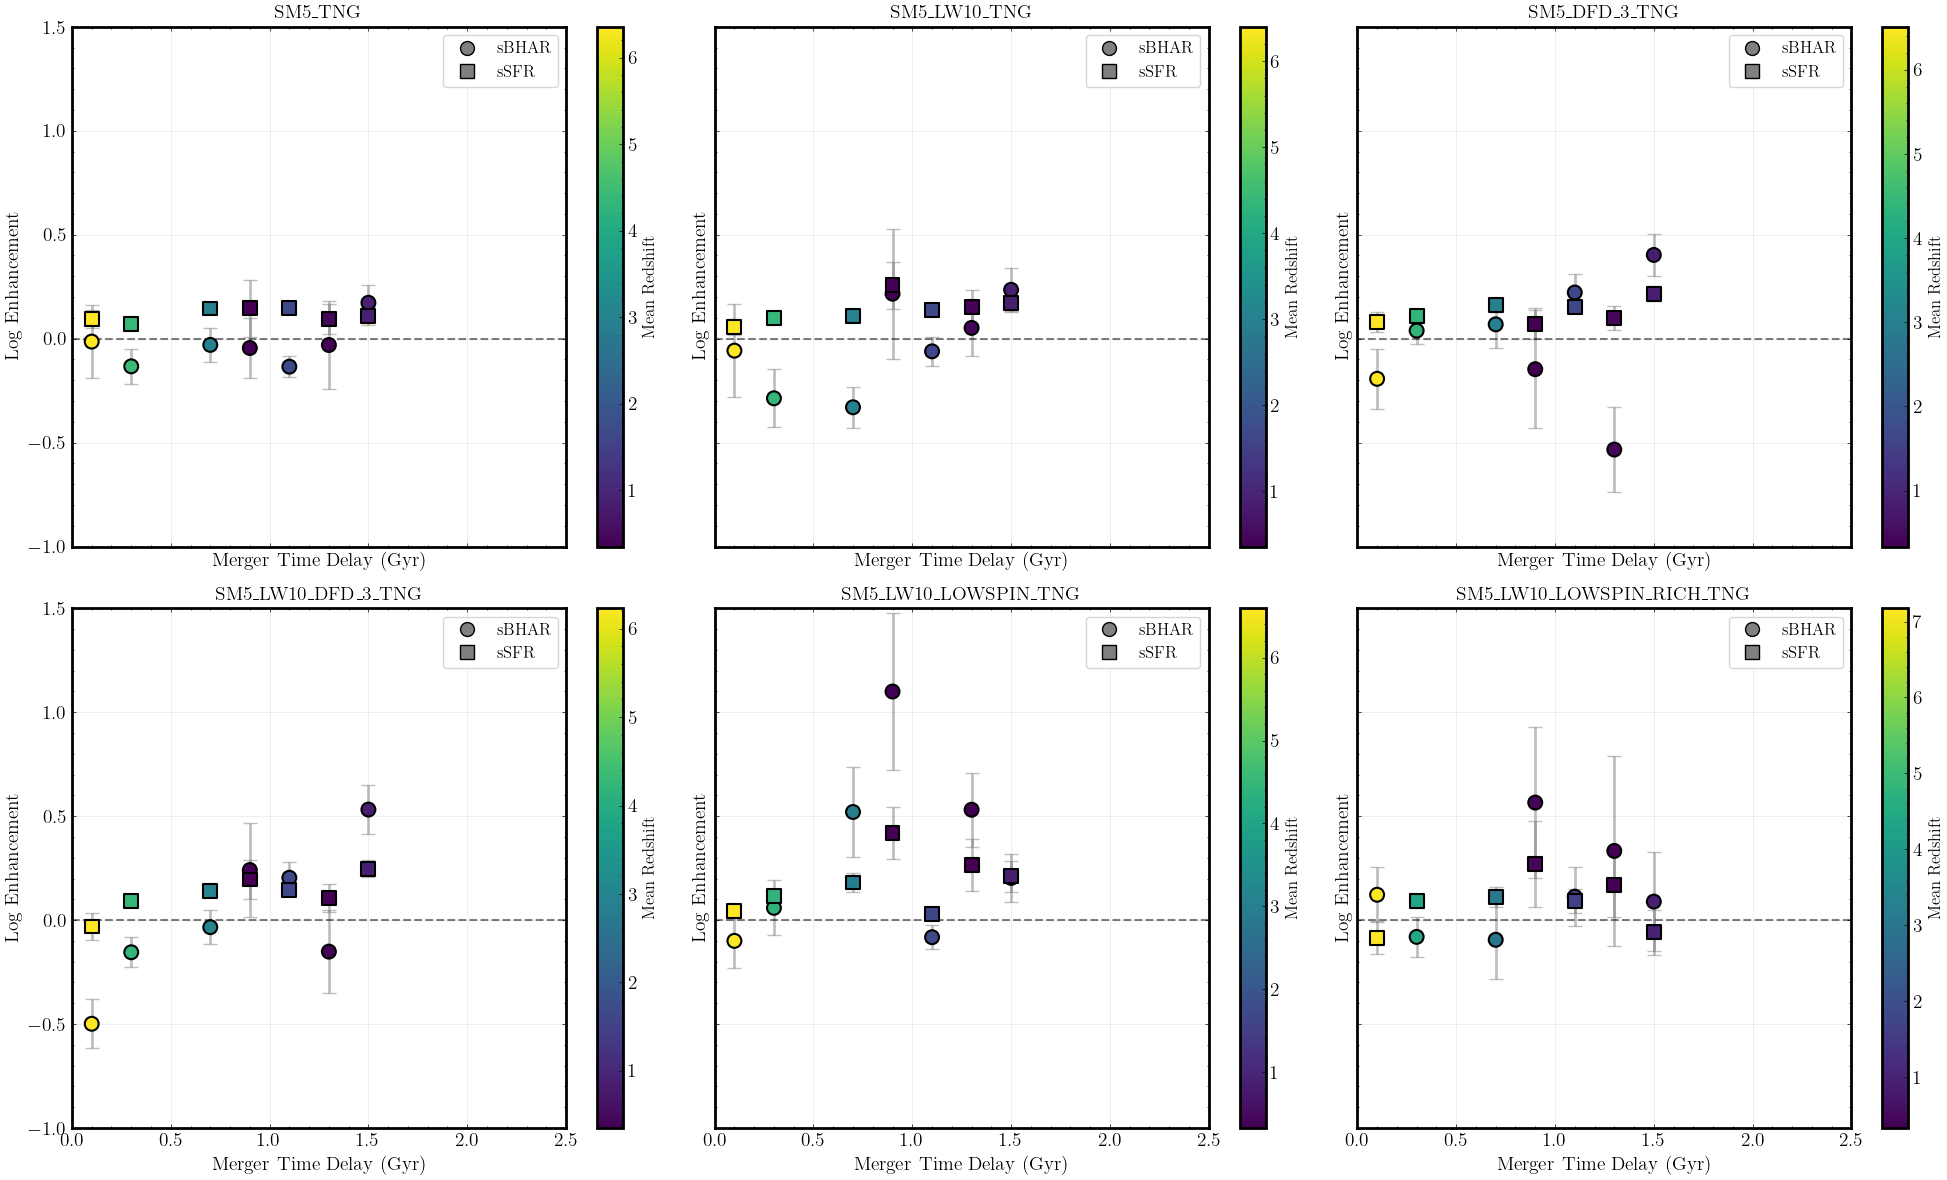

In [171]:
# Plot log enhancement (sBHAR and sSFR) vs merger time delay for BRAHMA simulations, binned by time delay
fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

hostplot.set_plot_style(spinewidth=2, linewidth=2, titlesize=16, labelsize=14, 
                        xlabelsize=14, ylabelsize=14, legendsize=10, bold=True)

td_bins = np.arange(0, 2.5, 0.2)  # Bins from 0 to 2.5 Gyr with 0.2 Gyr width

for idx, sim in enumerate(brahma_simName_array):
    ax = axes[idx]
    sim_obj = sim_objs[sim]
    # --- sBHAR ---
    sBHAR_merging = sim_obj.sBHAR_merging_pop
    sBHAR_control = sim_obj.sBHAR_control_pop
    log_sBHAR_enhancement = []
    merger_td = []
    redshifts_plot = []
    for i in range(len(sBHAR_merging)):
        if sBHAR_merging[i] > 0 and sBHAR_control[i] > 0:
            log_enh = np.log10(sBHAR_merging[i]) - np.log10(sBHAR_control[i])
            log_sBHAR_enhancement.append(log_enh)
            merger_td.append(merger_time_delay[sim]['td'][i])
            redshifts_plot.append(sim_obj.z_merging_pop[i])
    log_sBHAR_enhancement = np.array(log_sBHAR_enhancement)
    merger_td = np.array(merger_td)
    redshifts_plot = np.array(redshifts_plot)
    td_bin_centers = []
    mean_log_sBHAR = []
    std_log_sBHAR = []
    mean_redshift = []
    for i in range(len(td_bins) - 1):
        bin_mask = (merger_td >= td_bins[i]) & (merger_td < td_bins[i+1])
        if np.sum(bin_mask) > 0:
            td_bin_centers.append((td_bins[i] + td_bins[i+1]) / 2)
            mean_log_sBHAR.append(np.mean(log_sBHAR_enhancement[bin_mask]))
            std_log_sBHAR.append(stats.sem(log_sBHAR_enhancement[bin_mask]))
            mean_redshift.append(np.mean(redshifts_plot[bin_mask]))
    td_bin_centers = np.array(td_bin_centers)
    mean_log_sBHAR = np.array(mean_log_sBHAR)
    std_log_sBHAR = np.array(std_log_sBHAR)
    mean_redshift = np.array(mean_redshift)
    # --- sSFR ---
    sSFR_merging = sim_obj.sSFR_merging_pop
    sSFR_control = sim_obj.sSFR_control_pop
    log_sSFR_enhancement = []
    merger_td_sfr = []
    redshifts_plot_sfr = []
    for i in range(len(sSFR_merging)):
        if sSFR_merging[i] > 0 and sSFR_control[i] > 0:
            log_enh = np.log10(sSFR_merging[i]) - np.log10(sSFR_control[i])
            log_sSFR_enhancement.append(log_enh)
            merger_td_sfr.append(merger_time_delay[sim]['td'][i])
            redshifts_plot_sfr.append(sim_obj.z_merging_pop[i])
    log_sSFR_enhancement = np.array(log_sSFR_enhancement)
    merger_td_sfr = np.array(merger_td_sfr)
    redshifts_plot_sfr = np.array(redshifts_plot_sfr)
    td_bin_centers_sfr = []
    mean_log_sSFR = []
    std_log_sSFR = []
    mean_redshift_sfr = []
    for i in range(len(td_bins) - 1):
        bin_mask = (merger_td_sfr >= td_bins[i]) & (merger_td_sfr < td_bins[i+1])
        if np.sum(bin_mask) > 0:
            td_bin_centers_sfr.append((td_bins[i] + td_bins[i+1]) / 2)
            mean_log_sSFR.append(np.mean(log_sSFR_enhancement[bin_mask]))
            std_log_sSFR.append(stats.sem(log_sSFR_enhancement[bin_mask]))
            mean_redshift_sfr.append(np.mean(redshifts_plot_sfr[bin_mask]))
    td_bin_centers_sfr = np.array(td_bin_centers_sfr)
    mean_log_sSFR = np.array(mean_log_sSFR)
    std_log_sSFR = np.array(std_log_sSFR)
    mean_redshift_sfr = np.array(mean_redshift_sfr)
    # --- Plot both ---
    scatter1 = ax.scatter(td_bin_centers, mean_log_sBHAR, c=mean_redshift, marker='o',
                        cmap='viridis', s=100, edgecolors='black', linewidth=1.5, zorder=3, label='sBHAR')
    ax.errorbar(td_bin_centers, mean_log_sBHAR, yerr=std_log_sBHAR, 
                fmt='none', ecolor='gray', alpha=0.5, capsize=5, zorder=2)
    scatter2 = ax.scatter(td_bin_centers_sfr, mean_log_sSFR, c=mean_redshift_sfr, marker='s',
                        cmap='viridis', s=100, edgecolors='black', linewidth=1.5, zorder=3, label='sSFR')
    ax.errorbar(td_bin_centers_sfr, mean_log_sSFR, yerr=std_log_sSFR, 
                fmt='none', ecolor='gray', alpha=0.5, capsize=5, zorder=2)
    # Add colorbar for sBHAR (they share colormap)
    cbar = plt.colorbar(scatter1, ax=ax)
    cbar.set_label('Mean Redshift', fontsize=12)
    # Add reference line at y=0
    ax.axhline(0, ls='--', color='black', alpha=0.5, linewidth=1.5)
    # Labels and title
    ax.set_xlabel('Merger Time Delay (Gyr)', fontsize=14)
    ax.set_ylabel('Log Enhancement', fontsize=14)
    ax.set_title(f'{sim}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-1, 1.5)
    # Add legend for marker shapes
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='sBHAR', markerfacecolor='gray', markersize=10, markeredgecolor='black'),
        Line2D([0], [0], marker='s', color='w', label='sSFR', markerfacecolor='gray', markersize=10, markeredgecolor='black')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=True)
fig.tight_layout()
plt.show()